In [2]:
from datasets import dataloader_generator
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
# from models import brain_net_transformer, neuro_detour, brain_gnn, brain_identity, bolt, graphormer, nagphormer, vanilla_model
# from models import brain_identity, brain_net_transformer, neuro_detour, bolt, graphormer, nagphormer, vanilla_model
# from models.classifier import Classifier
from torch_geometric.nn import GCNConv#, GATConv, SAGEConv, SGConv
from tqdm import trange, tqdm
import torch.optim as optim
import torch.nn as nn
import torch, math
import argparse, os
import numpy as np
from datetime import datetime
from torch_geometric.data import Batch, Data


## Data

In [30]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, confusion_matrix, balanced_accuracy_score
from torchsampler import ImbalancedDatasetSampler
# from models import BECA
# from model_bank import brain_net_transformer, vanilla_model, brain_identity, brain_mass_models
from tqdm import trange, tqdm
import torch.optim as optim
import torch.nn as nn
import torch, math
import argparse, os
import numpy as np
from datetime import datetime
import warnings
from sklearn.exceptions import UndefinedMetricWarning
from torch.utils.data import Dataset, Subset, DataLoader, TensorDataset

# Suppress only this specific warning
warnings.filterwarnings('ignore', category=UndefinedMetricWarning)


In [31]:
fc_spd = pd.read_pickle('data/ukb-dwi-spd.pkl')
nagfeat = pd.read_pickle('data/ukb-dwi-nagfeat.pkl')


In [32]:
data = pd.read_pickle('data/ukb-nimg-dwi_icd10_dated.pkl')
data

,FC,FC_name,FC_date,FC_age (days),ICD10,ICD10_date,ICD10_age (days),Dementia,Dementia_date,Dementia_age (days),SC
1000026,"[[[0.9999999999999998, 0.4031736535288627, -0....",[sub-1000026_ses-2_task-hariri_space-MNI152NLi...,"[2015-07-30, 2015-07-30]","[25869, 25869]","[B980, D509, E780, E785, I10, I209, I251, J449...","[2021-09-29, 2021-09-29, 2016-02-29, 2016-05-0...","[28122, 28122, 26083, 26148, 26083, 26148, 260...",NaN,NaN,NaN,NaN
1000060,"[[[1.0, 0.6881473554050561, 0.1495016350062409...",[sub-1000060_ses-2_task-rest_space-MNI152NLin2...,"[2019-03-14, 2019-03-14]","[22109, 22109]","[D259, F419, G442, H268, I10, I441, K149, M179...","[2009-12-29, 2021-11-01, 2021-11-01, 2018-02-0...","[18747, 23072, 23072, 21711, 23072, 16061, 231...","[F419, G442]","[2021-11-01, 2021-11-01]","[23072, 23072]",NaN
1000102,"[[[1.0, 0.6343429578599622, -0.024345747736203...",[sub-1000102_ses-2_task-rest_space-MNI152NLin2...,[2018-12-10],[23872],NaN,NaN,NaN,NaN,NaN,NaN,NaN
1000139,"[[[1.0, 0.4480083117065995, 0.0640363923898662...",[sub-1000139_ses-2_task-rest_space-MNI152NLin2...,[2016-06-01],[28156],"[C329, D172, E780, F101, G409, H269, I252, I25...","[2010-03-29, 2010-03-29, 2007-09-17, 2018-08-1...","[25900, 25900, 24976, 28957, 22613, 24168, 289...","[F101, G409]","[2018-08-11, 2001-03-29]","[28957, 22613]",NaN
1000195,"[[[0.9999999999999998, 0.745800988424655, -0.3...",[sub-1000195_ses-2_task-hariri_space-MNI152NLi...,"[2018-01-18, 2018-01-18, 2021-05-26, 2021-05-26]","[19528, 19528, 20752, 20752]",NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
6022820,"[[[1.0, -0.0482714016850907, 0.308886073715980...",[sub-6022820_ses-2_task-hariri_space-MNI152NLi...,"[2015-06-01, 2015-06-01]","[22372, 22372]",NaN,NaN,NaN,NaN,NaN,NaN,NaN
6022900,"[[[1.0, 0.6585386095856742, 0.0177694108469557...",[sub-6022900_ses-2_task-hariri_space-MNI152NLi...,"[2019-10-02, 2019-10-02]","[24655, 24655]",[H431],[2015-02-09],[22959],NaN,NaN,NaN,NaN
6022917,"[[[1.0, 0.39577623816855567, -0.34633554747819...",[sub-6022917_ses-2_task-rest_space-MNI152NLin2...,[2018-08-25],[22031],"[I846, K509, K621, K623, K625, K628, K639, K90...","[2000-09-04, 2004-12-06, 2017-07-11, 2019-12-3...","[15467, 17021, 21621, 22524, 16026, 15467, 156...",NaN,NaN,NaN,NaN
6023116,"[[[1.0, 0.1645531818275878, 0.1133907388856572...",[sub-6023116_ses-3_task-hariri_space-MNI152NLi...,"[2021-02-03, 2021-02-03, 2014-06-25, 2014-06-25]","[20793, 20793, 18378, 18378]",[J330],[2003-01-23],[14207],NaN,NaN,NaN,NaN


In [33]:
if data['FC_date'].isna().iloc[-1]: print(1)

1


In [34]:
inbetween_list = []
for i in trange(data.shape[0]):
    if data['FC_date'].isna().iloc[i]: 
        inbetween_list.append(np.nan)
        continue
    if data['ICD10_date'].isna().iloc[i]: 
        inbetween_list.extend([False for _ in data['FC_date'].iloc[i]])
        continue
    inbetween_list.extend(
        [
            pd.to_datetime(xi) >= pd.to_datetime(data['ICD10_date'].iloc[i]).min() \
            and \
            pd.to_datetime(xi) <= pd.to_datetime(data['ICD10_date'].iloc[i]).max()
            for xi in data.iloc[i]['FC_date']]
    )

100%|████████████████████████████████████| 19930/19930 [01:10<00:00, 281.03it/s]


In [35]:
len(inbetween_list), sum(inbetween_list)

(51553, nan)

In [36]:
inbetween_list = np.array(inbetween_list)

In [37]:
inbetween_list[~np.isnan(inbetween_list)].sum()

np.float64(18483.0)

In [38]:
(~np.isnan(inbetween_list)).sum()

np.int64(50906)

In [39]:
data = data[~data['FC'].isna()]

In [40]:
data_dir = 'data'
delphi_train_data = np.memmap('../brain_env_ukb/data/delphi_train.bin', dtype=np.uint32, mode='r').reshape(-1, 3)
delphi_val_data = np.memmap('../brain_env_ukb/data/delphi_val.bin', dtype=np.uint32, mode='r').reshape(-1, 3)
# data['ICD10_grouped'] = data['ICD10'].map(lambda x: [xi[:3] for xi in x] if isinstance(x, list) else np.nan)
# data['ICD10_grouped']

In [41]:

remap_coding = pd.read_csv(f"/ram/USERS/ziquanw/data/meta_data/ukb_phenotype_info/data_coding/coding_000019.tsv", sep='\t', encoding_errors='ignore')

nodeid2coding = {row['node_id']: row['coding'] for _, row in remap_coding.iterrows()}
rootid = [i for i in remap_coding['parent_id'].unique() if i not in remap_coding['node_id'].tolist()]
topid = remap_coding[remap_coding['parent_id'].isin(rootid)]['node_id'].unique().tolist()
topid = [i for i in topid if i != 999999999]
# node2top = {remap_coding[remap_coding['node_id']==i]['coding'].item(): i for i in topid}
node2top = {}
for i in trange(len(remap_coding), desc=f'parse the tree of coding'):
    if remap_coding.iloc[i]['node_id'] == 999999999: continue
    # if remap_coding.iloc[i]['selectable']=='N': continue
    if remap_coding.iloc[i]['node_id'] in topid: continue
    j = i
    while True:
        if remap_coding.iloc[j]['parent_id'].item() in topid:
            node2top[remap_coding.iloc[i]['coding']] = nodeid2coding[remap_coding.iloc[j]['parent_id']].replace(' ', '-')
            break
        j = np.where(remap_coding['node_id'] == remap_coding.iloc[j]['parent_id'])[0].item()
for k in list(node2top.keys()):
    if isinstance(k, str):
        try:
            float(k)
            node2top[str(int(k))+'.0'] = node2top[k]
        except:
            pass
    else:
        node2top[str(k)] = node2top[k]
        node2top[str(k)+'.0'] = node2top[k]


parse the tree of coding: 100%|█████████| 19190/19190 [00:06<00:00, 2800.29it/s]


In [8]:
np.unique(list(node2top.values()))

array(['Chapter-I', 'Chapter-II', 'Chapter-III', 'Chapter-IV',
       'Chapter-IX', 'Chapter-V', 'Chapter-VI', 'Chapter-VII',
       'Chapter-VIII', 'Chapter-X', 'Chapter-XI', 'Chapter-XII',
       'Chapter-XIII', 'Chapter-XIV', 'Chapter-XIX', 'Chapter-XV',
       'Chapter-XVI', 'Chapter-XVII', 'Chapter-XVIII', 'Chapter-XX',
       'Chapter-XXI', 'Chapter-XXII'], dtype='<U13')

In [9]:
########### Group into chapter ####################
data['ICD10_grouped_v2'] = data['ICD10'].map(lambda x: [node2top[xi] for xi in x] if isinstance(x, list) else np.nan)
data['ICD10_grouped_v2']
vocab_grouped = []
vocab = []
for icd in data['ICD10']:
    if isinstance(icd, list):
        vocab_grouped.extend([node2top[i] for i in icd])
        vocab.extend(icd)


vocab_grouped = np.unique(vocab_grouped)
vocab = np.unique(vocab)
print(len(vocab_grouped), len(vocab))

22 5519


/tmp/ipykernel_7932/2827543703.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['ICD10_grouped_v2'] = data['ICD10'].map(lambda x: [node2top[xi] for xi in x] if isinstance(x, list) else np.nan)


array(['Chapter-I', 'Chapter-II', 'Chapter-III', 'Chapter-IV',
       'Chapter-IX', 'Chapter-V', 'Chapter-VI', 'Chapter-VII',
       'Chapter-VIII', 'Chapter-X', 'Chapter-XI', 'Chapter-XII',
       'Chapter-XIII', 'Chapter-XIV', 'Chapter-XIX', 'Chapter-XV',
       'Chapter-XVI', 'Chapter-XVII', 'Chapter-XVIII', 'Chapter-XX',
       'Chapter-XXI', 'Chapter-XXII'], dtype='<U13')

In [42]:
########### No group ####################
vocab_grouped = []
vocab = []
for icd in data['ICD10']:
    if isinstance(icd, list):
        vocab_grouped.extend([i[:3] for i in icd])
        vocab.extend(icd)


vocab_grouped = np.unique(vocab_grouped)
vocab = np.unique(vocab)
print(len(vocab_grouped), len(vocab))

1437 5519


In [10]:
columns = pd.read_csv('/ram/USERS/ziquanw/data/meta_data/UKB-nimg_phenotype.tsv', sep='\t', index_col='eid', nrows=0).columns


In [11]:
fid = [4259, 20016, 6351, 6373, 23324, 20139, 26302, 21004, 20197, 1558, 20116, 1200]
loadcols = [c for c in columns.tolist() if int(c.split('_')[0][1:]) in fid]
ukb_nimg_data = pd.read_csv('/ram/USERS/ziquanw/data/meta_data/UKB-nimg_phenotype.tsv', sep='\t', index_col='eid', usecols=['eid'] + loadcols)
ukb_nimg_data


,p1200_i0,p1200_i1,p1200_i2,p1200_i3,p1558_i0,p1558_i1,p1558_i2,p1558_i3,p4259_i0_a0,p4259_i0_a1,...,p20139_i2,p20139_i3,p20197_i2,p20197_i3,p21004_i2,p21004_i3,p23324_i2,p23324_i3,p26302_i2,p26302_i3
eid,,,,,,,,,,,,,,,,,,,,,
1000026,2.0,NaN,3.0,NaN,1.0,NaN,2.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1000060,2.0,NaN,2.0,NaN,1.0,NaN,1.0,NaN,NaN,NaN,...,NaN,NaN,4.0,NaN,8.0,NaN,20.0,NaN,0.3203,NaN
1000102,2.0,NaN,2.0,NaN,1.0,NaN,2.0,NaN,NaN,NaN,...,NaN,NaN,7.0,NaN,9.0,NaN,19.0,NaN,0.4409,NaN
1000139,2.0,2.0,2.0,NaN,1.0,3.0,3.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1000195,2.0,NaN,2.0,2.0,1.0,NaN,1.0,1.0,NaN,NaN,...,NaN,NaN,9.0,8.0,14.0,10.0,27.0,26.0,0.5727,0.4013
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6022820,1.0,NaN,2.0,NaN,2.0,NaN,2.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6022900,1.0,NaN,1.0,NaN,1.0,NaN,2.0,NaN,NaN,NaN,...,NaN,NaN,9.0,NaN,5.0,NaN,18.0,NaN,0.3884,NaN
6022917,1.0,NaN,2.0,2.0,6.0,NaN,6.0,6.0,NaN,NaN,...,NaN,27.0,7.0,8.0,10.0,NaN,23.0,19.0,0.2896,NaN


In [12]:
fid = 4259
ins2col = [c for c in columns.tolist() if int(c.split('_')[0][1:]) in [fid] and '_i2' in c]
beh_ins2 = ukb_nimg_data[ins2col].apply(lambda x: x[~x.isnull()].tolist() if not x.isnull().all() else np.nan, axis=1)
ins3col = [c for c in columns.tolist() if int(c.split('_')[0][1:]) in [fid] and '_i3' in c]
beh_ins3 = ukb_nimg_data[ins2col].apply(lambda x: x[~x.isnull()].tolist() if not x.isnull().all() else np.nan, axis=1)
data['num_mem_acc'] = data['FC_name'].map(lambda x: [np.mean(beh_ins2.loc[int(xi.split('_')[0][4:])]) if int(xi.split('_')[1].split('-')[1])==2 else np.mean(beh_ins3.loc[int(xi.split('_')[0][4:])]) for xi in x])
data['num_mem_acc']

/tmp/ipykernel_7932/3865433578.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['num_mem_acc'] = data['FC_name'].map(lambda x: [np.mean(beh_ins2.loc[int(xi.split('_')[0][4:])]) if int(xi.split('_')[1].split('-')[1])==2 else np.mean(beh_ins3.loc[int(xi.split('_')[0][4:])]) for xi in x])


1000026                                  [nan, nan]
1000060    [0.5714285714285714, 0.5714285714285714]
1000102                        [0.6666666666666666]
1000139                                       [nan]
1000195                        [0.7, 0.7, 0.7, 0.7]
                             ...                   
6022695    [0.7272727272727273, 0.7272727272727273]
6022820                                  [nan, nan]
6022900                              [0.625, 0.625]
6022917                        [0.7142857142857143]
6023116                        [nan, nan, nan, nan]
Name: num_mem_acc, Length: 19283, dtype: object

In [13]:
fid = 20016
ins2col = [c for c in columns.tolist() if int(c.split('_')[0][1:]) in [fid] and '_i2' in c]
beh_ins2 = ukb_nimg_data[ins2col].apply(lambda x: x[~x.isnull()].item() if not x.isnull().all() else np.nan, axis=1)
ins3col = [c for c in columns.tolist() if int(c.split('_')[0][1:]) in [fid] and '_i3' in c]
beh_ins3 = ukb_nimg_data[ins2col].apply(lambda x: x[~x.isnull()].item() if not x.isnull().all() else np.nan, axis=1)
data['fluid_intel'] = data['FC_name'].map(lambda x: [beh_ins2.loc[int(xi.split('_')[0][4:])] if int(xi.split('_')[1].split('-')[1])==2 else beh_ins3.loc[int(xi.split('_')[0][4:])] for xi in x])
data['fluid_intel']

/tmp/ipykernel_7932/182418866.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['fluid_intel'] = data['FC_name'].map(lambda x: [beh_ins2.loc[int(xi.split('_')[0][4:])] if int(xi.split('_')[1].split('-')[1])==2 else beh_ins3.loc[int(xi.split('_')[0][4:])] for xi in x])


1000026              [5.0, 5.0]
1000060              [2.0, 2.0]
1000102                   [7.0]
1000139                   [6.0]
1000195    [7.0, 7.0, 7.0, 7.0]
                   ...         
6022695              [7.0, 7.0]
6022820              [9.0, 9.0]
6022900              [6.0, 6.0]
6022917                   [5.0]
6023116    [3.0, 3.0, 3.0, 3.0]
Name: fluid_intel, Length: 19283, dtype: object

In [14]:
! which python

/ram/USERS/ziquanw/softwares/miniconda3/envs/flashattn3/bin/python


In [15]:
fids = [6351, 6373, 23324, 20139, 26302, 21004, 20197, 1558, 20116, 1200]
fidns = ['trail_error', 'puzzle_solved', 'symbol-digit_match', 'broken_letter', 'vocab_level', 'tower_game', 'word_match', 'alcohol_freq', 'smoking', 'sleepless']
for fid, fidn in zip(fids, fidns):
    ins2col = [c for c in columns.tolist() if int(c.split('_')[0][1:]) in [fid] and '_i2' in c]
    beh_ins2 = ukb_nimg_data[ins2col].apply(lambda x: x[~x.isnull()].item() if not x.isnull().all() else np.nan, axis=1)
    ins3col = [c for c in columns.tolist() if int(c.split('_')[0][1:]) in [fid] and '_i3' in c]
    beh_ins3 = ukb_nimg_data[ins2col].apply(lambda x: x[~x.isnull()].item() if not x.isnull().all() else np.nan, axis=1)
    data[fidn] = data['FC_name'].map(lambda x: [beh_ins2.loc[int(xi.split('_')[0][4:])] if int(xi.split('_')[1].split('-')[1])==2 else beh_ins3.loc[int(xi.split('_')[0][4:])] for xi in x])
data[fidns]

/tmp/ipykernel_7932/3794650683.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[fidn] = data['FC_name'].map(lambda x: [beh_ins2.loc[int(xi.split('_')[0][4:])] if int(xi.split('_')[1].split('-')[1])==2 else beh_ins3.loc[int(xi.split('_')[0][4:])] for xi in x])
/tmp/ipykernel_7932/3794650683.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[fidn] = data['FC_name'].map(lambda x: [beh_ins2.loc[int(xi.split('_')[0][4:])] if int(xi.split('_')[1].split('-')[1])==2 else beh_ins3.loc[int(xi.split('_')

,trail_error,puzzle_solved,symbol-digit_match,broken_letter,vocab_level,tower_game,word_match,alcohol_freq,smoking,sleepless
1000026,"[nan, nan]","[nan, nan]","[nan, nan]","[nan, nan]","[nan, nan]","[nan, nan]","[nan, nan]","[2.0, 2.0]","[1.0, 1.0]","[3.0, 3.0]"
1000060,"[0.0, 0.0]","[6.0, 6.0]","[20.0, 20.0]","[nan, nan]","[0.3203, 0.3203]","[8.0, 8.0]","[4.0, 4.0]","[1.0, 1.0]","[0.0, 0.0]","[2.0, 2.0]"
1000102,[3.0],[11.0],[19.0],[nan],[0.4409],[9.0],[7.0],[2.0],[0.0],[2.0]
1000139,[nan],[nan],[nan],[nan],[nan],[nan],[nan],[3.0],[1.0],[2.0]
1000195,"[0.0, 0.0, 0.0, 0.0]","[8.0, 8.0, 8.0, 8.0]","[27.0, 27.0, 27.0, 27.0]","[nan, nan, nan, nan]","[0.5727, 0.5727, 0.5727, 0.5727]","[14.0, 14.0, 14.0, 14.0]","[9.0, 9.0, 9.0, 9.0]","[1.0, 1.0, 1.0, 1.0]","[0.0, 0.0, 0.0, 0.0]","[2.0, 2.0, 2.0, 2.0]"
...,...,...,...,...,...,...,...,...,...,...
6022695,"[0.0, 0.0]","[10.0, 10.0]","[27.0, 27.0]","[nan, nan]","[0.3957, 0.3957]","[11.0, 11.0]","[9.0, 9.0]","[3.0, 3.0]","[0.0, 0.0]","[1.0, 1.0]"
6022820,"[nan, nan]","[nan, nan]","[nan, nan]","[nan, nan]","[nan, nan]","[nan, nan]","[nan, nan]","[2.0, 2.0]","[0.0, 0.0]","[2.0, 2.0]"
6022900,"[2.0, 2.0]","[8.0, 8.0]","[18.0, 18.0]","[nan, nan]","[0.3884, 0.3884]","[5.0, 5.0]","[9.0, 9.0]","[2.0, 2.0]","[0.0, 0.0]","[1.0, 1.0]"
6022917,[2.0],[8.0],[23.0],[nan],[0.2896],[10.0],[7.0],[6.0],[0.0],[2.0]


In [17]:
data.rename(columns={'ICD10_grouped_v2': 'ICD10_chapter'}).to_pickle('data/ukb-nimg-dwi_icd10-beh_dated_flashattn3env.pkl')

In [19]:
fnlist = os.listdir('../data/UKB-SC-FC/ALL_SC')
fnlist = [fn for fn in fnlist if 'S' not in fn.split('_')[0][4:]]
fnlist = np.array(fnlist)
fneid = np.array([int(fn.split('_')[0][4:]) for fn in fnlist])
dwi_path = ukb_nimg_data.index.to_series().map(lambda x: fnlist[fneid==x].tolist())
dwi_path = dwi_path.map(lambda x: x if len(x) > 0 else np.nan)
dwi_path = dwi_path.dropna()
dwi_path

eid
1001159    [sub-1001159_ses-2_space-T1w_desc-preproc_msmt...
1001755    [sub-1001755_ses-2_space-T1w_desc-preproc_msmt...
1001763    [sub-1001763_ses-2_space-T1w_desc-preproc_msmt...
1002138    [sub-1002138_ses-2_space-T1w_desc-preproc_msmt...
1002156    [sub-1002156_ses-2_space-T1w_desc-preproc_msmt...
                                 ...                        
5999780    [sub-5999780_ses-2_space-T1w_desc-preproc_msmt...
6003309    [sub-6003309_ses-2_space-T1w_desc-preproc_msmt...
6003907    [sub-6003907_ses-2_space-T1w_desc-preproc_msmt...
6003924    [sub-6003924_ses-2_space-T1w_desc-preproc_msmt...
6004118    [sub-6004118_ses-2_space-T1w_desc-preproc_msmt...
Name: eid, Length: 4226, dtype: object

In [20]:
fc_thr = 0.5
sc_thr = 0.1
all_subjects = []
multiclass_labels = []
tasks = []
first_occurs = []
last_occurs = []
xs = []
xadjscs = []
xadjfcs = []
xspd_dists = []
xnagfeats = []
xedges = []
xages = []
valid_mask = []
sc_cache = {}
tgt_key = 'ICD10_grouped_v2'
nan_idx = data.index[data[tgt_key].isna()].tolist()
for i, row in tqdm(data.iterrows(), total=len(data)):
    if i not in dwi_path.index: continue
    xspd_dists.extend(fc_spd.loc[i])
    xnagfeats.extend(nagfeat.loc[i])
    xadjscs.extend((row['SC']>sc_thr)[None].repeat(len(row['FC']), 0))
    xadjfcs.extend(row['FC']>fc_thr)
    all_subjects.extend([n.split('_')[0] for n in row['FC_name']])
    tasks.extend([n.split('_')[2] for n in row['FC_name']])
    xs.extend(row['FC'])
    xages.extend(row['FC_age (days)'])
    xedges.extend([np.stack(np.where(fc>fc_thr), -1) for fc in row['FC']])
    valid_mask.extend(~np.isnan(row['FC']).any(-1).any(-1))
    
    if i in nan_idx:
        multiclass_labels.extend([np.zeros(len(vocab_grouped)).tolist() for x in row['FC']])
        first_occurs.extend([np.zeros(len(vocab_grouped)).tolist() for x in row['FC']])
        last_occurs.extend([np.zeros(len(vocab_grouped)).tolist() for x in row['FC']])
    else:
        for x, xage in zip(row['FC'], row['FC_age (days)']):
            has_icd = np.isin(vocab_grouped, row[tgt_key])
            first_occur = np.zeros(len(vocab_grouped))
            last_occur = np.zeros(len(vocab_grouped))
            for l in np.unique(row[tgt_key]):
                first_occur[vocab_grouped.tolist().index(l)] = int(np.array(row['ICD10_age (days)'])[np.array(row[tgt_key])==l].min())
                last_occur[vocab_grouped.tolist().index(l)] = int(np.array(row['ICD10_age (days)'])[np.array(row[tgt_key])==l].max())
            
            first_occurs.append(first_occur.tolist())
            last_occurs.append(last_occur.tolist())
            multiclass_labels.append(has_icd.astype(int).tolist())

    # if len(xs) >= 100: break
valid_mask = np.stack(valid_mask)
xs = np.stack(xs)[valid_mask]
xages = np.stack(xages)[valid_mask]
xedges = [xedges[i] for i in np.where(valid_mask)[0]]
multiclass_labels = np.array(multiclass_labels)[valid_mask]
first_occurs = np.array(first_occurs)[valid_mask]
last_occurs = np.array(last_occurs)[valid_mask]
all_subjects = np.array(all_subjects)[valid_mask]
tasks = np.array(tasks)[valid_mask]
xadjscs = np.array(xadjscs)[valid_mask]
xadjfcs = np.array(xadjfcs)[valid_mask]
xspd_dists = np.array(xspd_dists)[valid_mask]
xnagfeats = np.array(xnagfeats)[valid_mask]


100%|███████████████████████████████████| 19283/19283 [00:02<00:00, 7799.62it/s]


In [21]:
pos_ratio = multiclass_labels.sum(0)/multiclass_labels.shape[0]
print('\t'.join(vocab_grouped))
print('\t\t'.join([f'{r:.5f}' for r in pos_ratio]))

Chapter-I	Chapter-II	Chapter-III	Chapter-IV	Chapter-IX	Chapter-V	Chapter-VI	Chapter-VII	Chapter-VIII	Chapter-X	Chapter-XI	Chapter-XII	Chapter-XIII	Chapter-XIV	Chapter-XIX	Chapter-XV	Chapter-XVI	Chapter-XVII	Chapter-XVIII	Chapter-XX	Chapter-XXI	Chapter-XXII
0.08276		0.26858		0.06938		0.21509		0.33014		0.08717		0.10319		0.14772		0.03305		0.15744		0.45011		0.12716		0.31210		0.26227		0.13940		0.05803		0.00013		0.01186		0.39763		0.14419		0.53425		0.01678


In [22]:
len(xs), xadjfcs.shape

(7927, (7927, 116, 116))

In [25]:
train_subjects = [f'sub-{i}' for i in np.unique(delphi_train_data[:, 0])]
val_subjects = [f'sub-{i}' for i in np.unique(delphi_val_data[:, 0])]
train_idx = [di for di, subj in enumerate(all_subjects) if subj in train_subjects]
val_idx = [di for di, subj in enumerate(all_subjects) if subj in val_subjects]
print(len(train_subjects), len(val_subjects), len(train_idx), len(val_idx))

13697 3425 5437 1322


In [26]:
device = 'cuda:0'
xs_tensor = torch.from_numpy(xs).float()#.to(device)
ys_tensor = torch.from_numpy(multiclass_labels).long()#.to(device)
xyedge_datalist = []
for i in trange(len(xs)):
    # xyedge_datalist.append(Data(x=xs_tensor[i], edge_index=torch.from_numpy(xedges[i]).long().to(device).T, y=ys_tensor[i:i+1]))
    # xyedge_datalist.append(Data(x=xs_tensor[i], adj_sc=torch.from_numpy(xadjscs[i:i+1]).to(device), adj_fc=torch.from_numpy(xadjfcs[i:i+1]).to(device), y=ys_tensor[i:i+1]))
    xyedge_datalist.append(Data(
        x=xs_tensor[i], 
        adj_sc=torch.from_numpy(xadjscs[i:i+1]), 
        adj_fc=torch.from_numpy(xadjfcs[i:i+1]), 
        spd_dist=torch.from_numpy(xspd_dists[i:i+1]),
        new_feature=torch.from_numpy(xnagfeats[i]),
        edge_index=torch.from_numpy(xedges[i]).long().T,
        y=ys_tensor[i:i+1]))


100%|████████████████████████████████████| 7927/7927 [00:00<00:00, 13340.16it/s]


In [27]:
batch_size = 32
val_batches = [Batch.from_data_list([xyedge_datalist[idxi] for idxi in val_idx[bi : bi+batch_size]]) for bi in trange(0, len(val_idx), batch_size, desc='prepare val batches')]

prepare val batches: 100%|█████████████████████| 42/42 [00:00<00:00, 105.95it/s]


## Evaluator

In [28]:


# AUC comparison adapted from
# https://github.com/Netflix/vmaf/
def compute_midrank(x):
    """Computes midranks.
    Args:
       x - a 1D numpy array
    Returns:
       array of midranks
    """
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N, dtype=np.float32)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1)
        i = j
    T2 = np.empty(N, dtype=np.float32)
    # Note(kazeevn) +1 is due to Python using 0-based indexing
    # instead of 1-based in the AUC formula in the paper
    T2[J] = T + 1
    return T2


def fastDeLong(predictions_sorted_transposed, label_1_count):
    """
    The fast version of DeLong's method for computing the covariance of
    unadjusted AUC.
    Args:
       predictions_sorted_transposed: a 2D numpy.array[n_classifiers, n_examples]
          sorted such as the examples with label "1" are first
    Returns:
       (AUC value, DeLong covariance)
    Reference:
     @article{sun2014fast,
       title={Fast Implementation of DeLong's Algorithm for
              Comparing the Areas Under Correlated Receiver Operating Characteristic Curves},
       author={Xu Sun and Weichao Xu},
       journal={IEEE Signal Processing Letters},
       volume={21},
       number={11},
       pages={1389--1393},
       year={2014},
       publisher={IEEE}
     }
    """
    # Short variables are named as they are in the paper
    m = label_1_count
    n = predictions_sorted_transposed.shape[1] - m
    positive_examples = predictions_sorted_transposed[:, :m]
    negative_examples = predictions_sorted_transposed[:, m:]
    k = predictions_sorted_transposed.shape[0]

    tx = np.empty([k, m], dtype=np.float32)
    ty = np.empty([k, n], dtype=np.float32)
    tz = np.empty([k, m + n], dtype=np.float32)
    for r in range(k):
        tx[r, :] = compute_midrank(positive_examples[r, :])
        ty[r, :] = compute_midrank(negative_examples[r, :])
        tz[r, :] = compute_midrank(predictions_sorted_transposed[r, :])
    aucs = tz[:, :m].sum(axis=1) / m / n - float(m + 1.0) / 2.0 / n
    v01 = (tz[:, :m] - tx[:, :]) / n
    v10 = 1.0 - (tz[:, m:] - ty[:, :]) / m
    sx = np.cov(v01)
    sy = np.cov(v10)
    delongcov = sx / m + sy / n
    return aucs, delongcov


def compute_ground_truth_statistics(ground_truth):
    assert np.array_equal(np.unique(ground_truth), [0, 1])
    order = (-ground_truth).argsort()
    label_1_count = int(ground_truth.sum())
    return order, label_1_count


def get_auc_delong_var(healthy_scores, diseased_scores):
    """
    Computes ROC AUC value and variance using DeLong's method

    Args:
        healthy_scores: Values for class 0 (healthy/controls)
        diseased_scores: Values for class 1 (diseased/cases)
    Returns:
        AUC value and variance
    """
    # Create ground truth labels (1 for diseased, 0 for healthy)
    ground_truth = np.array([1] * len(diseased_scores) + [0] * len(healthy_scores))
    predictions = np.concatenate([diseased_scores, healthy_scores])

    # Compute statistics needed for DeLong method
    order, label_1_count = compute_ground_truth_statistics(ground_truth)
    predictions_sorted_transposed = predictions[np.newaxis, order]

    # Calculate AUC and covariance
    aucs, delongcov = fastDeLong(predictions_sorted_transposed, label_1_count)
    assert len(aucs) == 1, "There is a bug in the code, please forward this to the developers"

    return aucs[0], delongcov


In [29]:
device

'cuda:0'

In [30]:
# device = 'cuda:6'
ages = first_occurs.copy()
ages[ages==0] = last_occurs[ages==0]

all_control_ages_max = []
all_control_ages_min = []
val_ages = torch.from_numpy(ages[val_idx])
vocab_idx = torch.arange(val_ages.shape[1])
for mi in trange(ages.shape[1], desc='prepare control ages'):
    p_val_ages = val_ages[:, vocab_idx[vocab_idx!=mi]].to(device)
    control_ages_max = p_val_ages.max(-1)[0]
    control_ages_min = torch.sort(p_val_ages, -1)[0][torch.arange(len(p_val_ages)), -1*(p_val_ages!=0).sum(-1)]
    all_control_ages_max.append(control_ages_max)
    all_control_ages_min.append(control_ages_min)


prepare control ages: 100%|█████████████████████| 22/22 [00:01<00:00, 21.97it/s]


In [31]:

all_control_ages_max = torch.stack(all_control_ages_max, -1).detach().cpu().numpy()
all_control_ages_min = torch.stack(all_control_ages_min, -1).detach().cpu().numpy()


In [32]:
auc_df_dict = {}

In [33]:
import os
import torch
from tqdm import tqdm
import pandas as pd
import numpy as np
import textwrap
import matplotlib.pyplot as plt
%config InlineBackend.figure_format='retina'

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams.update({'axes.grid': True,
                     'grid.linestyle': ':',
                     'axes.spines.bottom': False,
          'axes.spines.left': False,
          'axes.spines.right': False,
          'axes.spines.top': False})
plt.rcParams['figure.dpi'] = 72
plt.rcParams['pdf.fonttype'] = 42

#Green
light_male = '#BAEBE3'
normal_male = '#0FB8A1'
dark_male = '#00574A'


#Purple
light_female = '#DEC7FF'
normal_female = '#8520F1'
dark_female = '#7A00BF'

In [34]:
def aggregate_normals(group):
    n = len(group)
    mean = group['auc_delong'].mean()
    # Since we're taking the average, divide combined variance by n^2
    var = group['auc_variance_delong'].sum() / (n**2)
    return pd.Series({
        'auc': mean,
        'auc_variance_delong': var,
        'n_groups': n, 
        'n_diseased': group['n_diseased'].sum(),
        'n_healthy': group['n_healthy'].sum(),
    })


In [35]:
np_softmax = lambda x: np.exp(x - np.max(x, -1)[:, None])

In [36]:
# device = 'cuda:2'
age_groups = np.arange(xages.min(), xages.max(), int(5*365.25))
age_step = age_groups[1] - age_groups[0]

## MLP

In [37]:
batch_size = 32
class MLP(nn.Module):
    def __init__(self, in_channel, out_channel, hid_channel=768, **kwargs) -> None:
        super().__init__()
        self.layers = torch.nn.Sequential(
                nn.Linear(in_channel, hid_channel),
                nn.BatchNorm1d(hid_channel),
                nn.LeakyReLU(),
                nn.Linear(hid_channel, hid_channel),
                nn.BatchNorm1d(hid_channel),
                nn.LeakyReLU(),
                nn.Linear(hid_channel, out_channel)
            )

    def forward(self, batch):
        return self.layers(batch['x'])

def multiclass_eval(i, classifier, device, loader, return_pred=False):
    # classifier.to(device)
    classifier.eval()
    y_true = []
    y_pred = []
    y_scores = []
    losses = []
    loss_fn = nn.CrossEntropyLoss()
    for bi in range(0, len(val_idx), batch_size):
        idx = val_idx[bi : bi+batch_size]
        x, y = xs_tensor[idx].to(device), ys_tensor[idx].to(device)
        batch = {'x': x.reshape(len(x), -1).float(), 'y': y[:, i]}
        with torch.no_grad():
            y = classifier(batch) 
            loss = loss_fn(y.float(), batch['y'].long())
        if return_pred:
            # y_scores.append(y[torch.arange(len(y)), batch['y']].detach().cpu())
            y_scores.append(y.detach().cpu())
            y_pred.append(y.argmax(1).detach().cpu())
            y_true.append(batch['y'])
        losses.append(loss.detach().cpu().item())

    if return_pred:
        y_true = torch.cat(y_true, dim = 0).detach().cpu().numpy()
        y_pred = torch.cat(y_pred, dim = 0).detach().cpu().numpy()
        y_scores = torch.cat(y_scores, dim = 0).detach().cpu().numpy()
        return np.mean(losses), y_true, y_pred, y_scores
    else:
        return np.mean(losses)



### eval AUC

In [38]:
mi = 0
model = torch.load(f'baseline_MLP-grouped_out/ckpt_{vocab_grouped[mi]}.ckpt', weights_only=False)['ckpt'].to(device)
_, gt, preds, scores = multiclass_eval(mi, model, device, None, return_pred=True)

In [39]:
gt.shape, len(val_idx)

((1322,), 1322)

In [40]:
case = np_softmax(scores)[(gt==1), 1]
control = np_softmax(scores)[(gt==0), 1]
get_auc_delong_var(control, case)

(0.46500728, 0.0006857751265470037)

In [41]:
pos_ratio.argsort()[-100:]

array([16, 17, 21,  8, 15,  2,  0,  5,  6, 11, 14, 19,  7,  9,  3, 13,  1,
       12,  4, 18, 10, 20])

In [42]:

all_aucs = []
# for mi in trange(len(vocab_grouped)):
for mi in tqdm(pos_ratio.argsort()[-100:]):
    model = torch.load(f'baseline_MLP-grouped_out/ckpt_{vocab_grouped[mi]}.ckpt', weights_only=False)['ckpt']
    # if model is None: continue
    if not isinstance(model, MLP): 
        model_f = MLP(in_channel=xs[0].shape[1]**2, out_channel=2)
        model_f.load_state_dict(model)
        model = model_f
    model = model.to(device)
    assert isinstance(model, nn.Module)
    _, gt, preds, scores = multiclass_eval(mi, model, device, None, return_pred=True)
    scores = np_softmax(scores)
    model.cpu()
    age = ages[val_idx, mi]
    control_ages_max = all_control_ages_max[:, mi]
    control_ages_min = all_control_ages_min[:, mi]
    for i, aa in enumerate(age_groups):
        case = scores[(age >= aa) & (age < aa + age_step) & (gt==1)]
        control = scores[((control_ages_max >= aa) & (control_ages_max < aa + age_step)) | \
            ((control_ages_min >= aa) & (control_ages_min < aa + age_step)) & \
            (gt==0)]
        control = control[:, 1]
        case = case[:, 1]
        if len(control) == 0 or len(case) == 0:
            continue
        
        auc_value_delong, auc_variance_delong = get_auc_delong_var(control, case)
        auc_delong_dict = {"auc_delong": auc_value_delong, "auc_variance_delong": auc_variance_delong}

        out_item = {
            "token": mi,
            "name": vocab_grouped[mi],
            "auc": auc_value_delong,
            "age": aa,
            "n_healthy": len(control),
            "n_diseased": len(case),
            "case_score": case,
            "control_score": control,
        }
        all_aucs.append(out_item | auc_delong_dict)
        


 14%|██████                                      | 3/22 [00:01<00:10,  1.86it/s]/tmp/ipykernel_7932/3540653806.py:67: RuntimeWarning: Degrees of freedom <= 0 for slice
  sx = np.cov(v01)
/ram/USERS/ziquanw/softwares/miniconda3/envs/flashattn3/lib/python3.12/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/ram/USERS/ziquanw/softwares/miniconda3/envs/flashattn3/lib/python3.12/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
100%|███████████████████████████████████████████| 22/22 [00:13<00:00,  1.59it/s]


In [44]:
auc_df_all_brackets = pd.DataFrame(all_aucs)
auc_df_all_brackets.to_csv('mia-exp_eval_out/auc_df_age-separate_MLP-grouped.csv')
auc_df = auc_df_all_brackets.groupby(['token']).apply(aggregate_normals, include_groups=False).reset_index()
auc_df['name'] = np.array(vocab_grouped)[auc_df['token']]
auc_df['n'] = auc_df['n_diseased']+auc_df['n_healthy']
auc_df = auc_df.sort_values(by='name', ascending=False)
auc_df.to_csv('mia-exp_eval_out/auc_df_age-grouped_MLP-grouped.csv')
auc_df_dict['MLP'] = auc_df
# dementia_auc_df = auc_df[auc_df['name'].map(lambda x: x[0] in ['F', 'G'])]

print(auc_df)


    token       auc  auc_variance_delong  n_groups  n_diseased  n_healthy  \
20     21  0.483023             0.003579       6.0        33.0     1581.0   
19     20  0.502938             0.000075       8.0       654.0     1388.0   
18     19  0.485012             0.000934       8.0       195.0     1727.0   
17     18  0.538738             0.000661       8.0       556.0     1473.0   
16     17  0.644220             0.003247       6.0        21.0     1720.0   
15     15  0.533730             0.152995       1.0         2.0      252.0   
14     14  0.506891             0.000636       8.0       181.0     1733.0   
13     13  0.528005             0.000423       8.0       367.0     1602.0   
12     12  0.507067             0.000585       8.0       443.0     1534.0   
11     11  0.544177             0.000787       8.0       155.0     1744.0   
10     10  0.499732             0.000012       8.0       615.0     1393.0   
9       9  0.497140             0.000590       8.0       209.0     1719.0   

52.14+-4.19


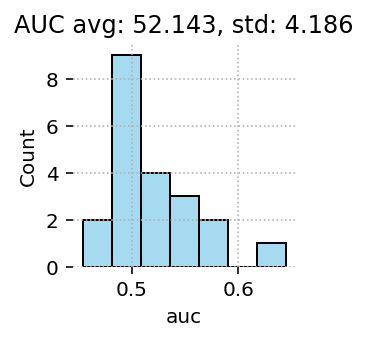

In [45]:
import seaborn as sns
log = f"AUC avg: {auc_df['auc'].mean()*100:.3f}, std: {auc_df['auc'].std()*100:.3f}"
plt.figure(figsize=(2,2))
sns.histplot(auc_df['auc'], color='skyblue')
plt.title(log)
print(f"{auc_df['auc'].mean()*100:.2f}+-{auc_df['auc'].std()*100:.2f}")
# print(f"{dementia_auc_df['auc'].mean()*100:.2f}+-{dementia_auc_df['auc'].std()*100:.2f}")

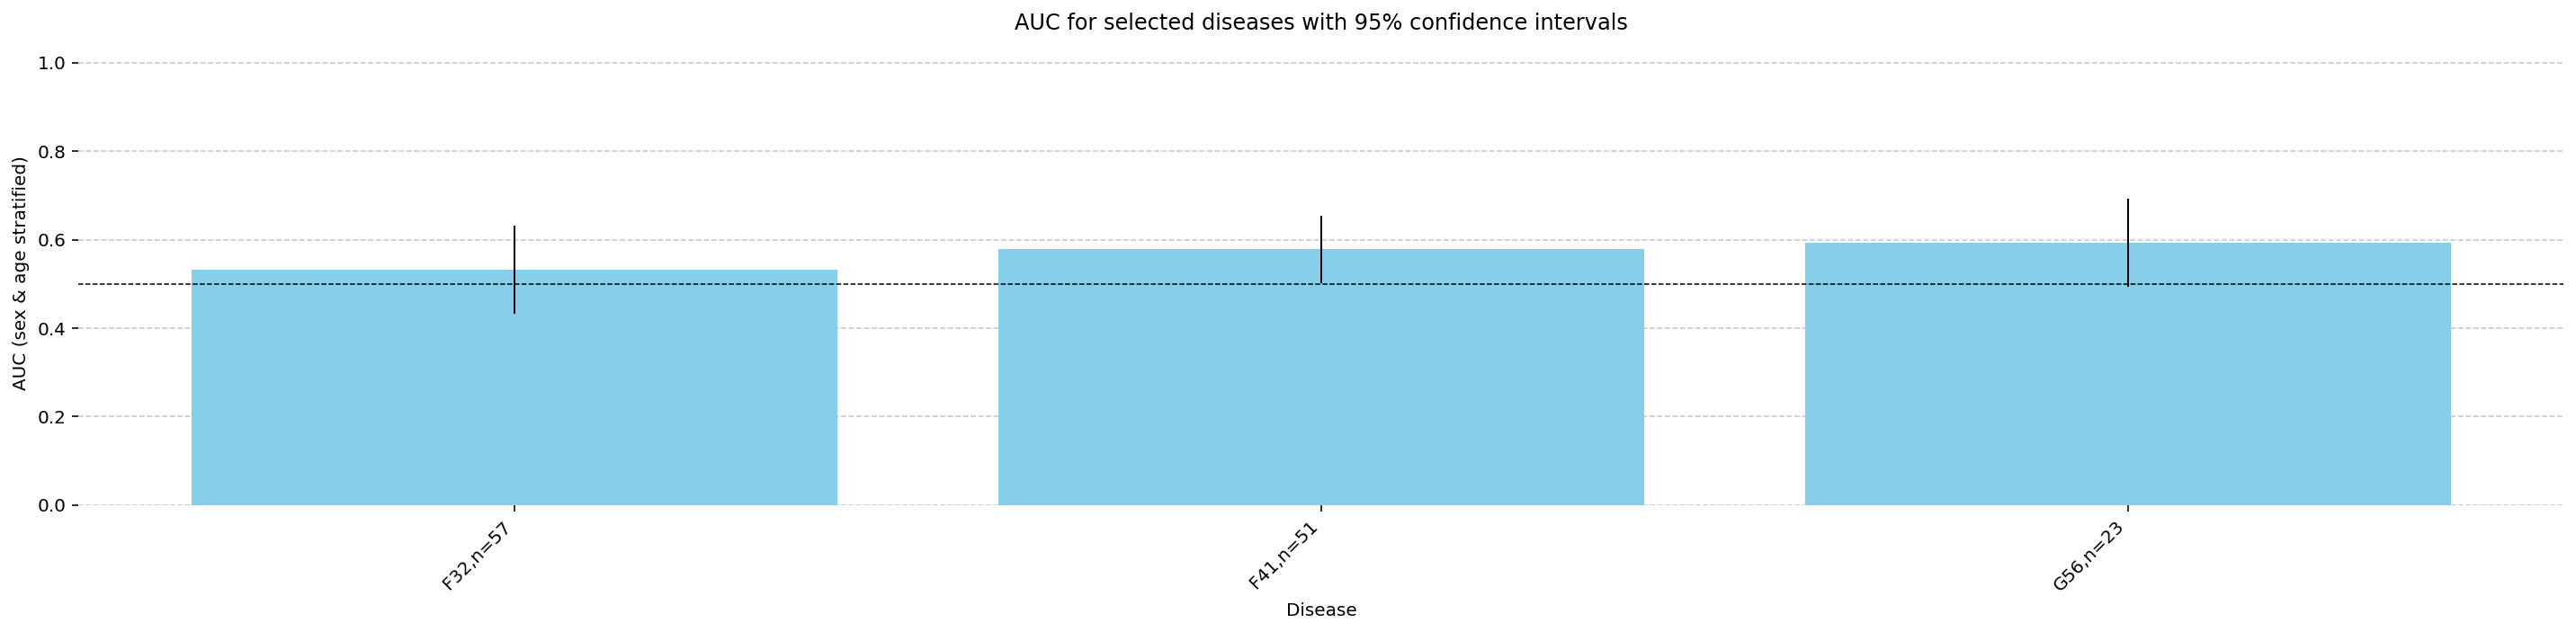

In [105]:
dementia_auc_df = dementia_auc_df.sort_values(by='n_diseased', ascending=False)
plt.figure(figsize=(20, 5))

# Create the bar chart
bars = plt.bar(range(len(dementia_auc_df)), dementia_auc_df['auc'], color='skyblue')

plt.errorbar(
    range(len(dementia_auc_df)), 
    dementia_auc_df['auc'], 
    yerr=1.96 * np.sqrt(dementia_auc_df['auc_variance_delong']),
    fmt='none', 
    color='black', 
    capsize=0,
    linewidth=1.0,
)

# Add labels and title
plt.xlabel('Disease')
plt.ylabel('AUC (sex & age stratified)')
plt.title('AUC for selected diseases with 95% confidence intervals')
plt.xticks(range(len(dementia_auc_df)), dementia_auc_df['name']+',n='+dementia_auc_df['n_diseased'].astype(int).astype(str), rotation=45, ha='right')
plt.gca().set_axisbelow(True)
plt.grid(axis='x', visible=False)
plt.axhline(0.5, color='k', linestyle='--', linewidth=0.75)
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

## GCN

In [46]:

from torch_geometric.data import Batch, Data
from torch_geometric.nn import GCNConv
class GCN(nn.Module):
    def __init__(self, in_channel, out_channel, hid_channel=768, **kwargs) -> None:
        super().__init__()
        self.dropout = 0.1
        self.node_sz = 116
        self.lin_in = nn.Linear(in_channel, hid_channel)
        self.net = nn.ModuleList([
            GCNConv(hid_channel, hid_channel),
            # nn.LeakyReLU(),
            GCNConv(hid_channel, hid_channel),
            # nn.LeakyReLU(),
        ])
        self.act = nn.LeakyReLU()
        self.lin_node = nn.Linear(self.node_sz, 1)
        self.lin_out = nn.Linear(hid_channel, out_channel)

    def forward(self, batch):
        x = self.lin_in(batch['x'])
        for net in self.net:
            x = torch.nn.functional.dropout(x, self.dropout, training=self.training)
            x = self.act(net(x, batch['edge_index']))
        
        x = torch.stack(x.split(self.node_sz)).permute(0, 2, 1)
        x = self.lin_node(x)[..., 0]
        return self.lin_out(x)
        
def multiclass_eval(i, classifier, device, loader, return_pred=False):
    classifier.eval()
    y_true = []
    y_pred = []
    y_scores = []
    losses = []
    loss_fn = nn.CrossEntropyLoss()
    
    for batch in loader:
        gt = batch['y'][:, i].to(device)
        with torch.no_grad():
            y = classifier(batch.to(device)) 
            loss = loss_fn(y.float(), gt.long())
        if return_pred:
            y_scores.append(y.detach().cpu())
            y_pred.append(y.argmax(1).detach().cpu())
            y_true.append(gt.detach().cpu())
        losses.append(loss.detach().cpu().item())

    if return_pred:
        y_true = torch.cat(y_true, dim = 0).detach().cpu().numpy()
        y_pred = torch.cat(y_pred, dim = 0).detach().cpu().numpy()
        y_scores = torch.cat(y_scores, dim = 0).detach().cpu().numpy()
        return np.mean(losses), y_true, y_pred, y_scores
    else:
        return np.mean(losses)

### eval AUC

In [47]:
mi = 0
model = torch.load(f'baseline_GCN-grouped_out/ckpt_{vocab_grouped[mi]}.ckpt', weights_only=False)['ckpt'].to(device)
_, gt, preds, scores = multiclass_eval(mi, model, device, val_batches, return_pred=True)

In [48]:
gt.shape, scores.shape, len(val_idx)

((1322,), (1322, 2), 1322)

In [49]:
case = np_softmax(scores)[(gt==1), 1]
control = np_softmax(scores)[(gt==0), 1]
get_auc_delong_var(control, case)

(0.5515831, 0.0008483707096700412)

In [50]:
# device = 'cuda:1'
all_aucs = []
for mi in tqdm(pos_ratio.argsort()[-100:]):
# for mi in trange(len(vocab_grouped)):
    model = torch.load(f'baseline_GCN-grouped_out/ckpt_{vocab_grouped[mi]}.ckpt', weights_only=False)['ckpt']
    # if model is None: continue
    if not isinstance(model, GCN): 
        model_f = GCN(in_channel=xs[0].shape[1], out_channel=2)
        model_f.load_state_dict(model)
        model = model_f
    model = model.to(device)
    assert isinstance(model, nn.Module)
    _, gt, preds, scores = multiclass_eval(mi, model, device, val_batches, return_pred=True)
    scores = np_softmax(scores)
    model.cpu()
    age = ages[val_idx, mi]
    control_ages_max = all_control_ages_max[:, mi]
    control_ages_min = all_control_ages_min[:, mi]
    for i, aa in enumerate(age_groups):
        case = scores[(age >= aa) & (age < aa + age_step) & (gt==1)]
        control = scores[((control_ages_max >= aa) & (control_ages_max < aa + age_step)) | \
            ((control_ages_min >= aa) & (control_ages_min < aa + age_step)) & \
            (gt==0)]
        control = control[:, 1]
        case = case[:, 1]
        if len(control) == 0 or len(case) == 0:
            continue
        
        auc_value_delong, auc_variance_delong = get_auc_delong_var(control, case)
        auc_delong_dict = {"auc_delong": auc_value_delong, "auc_variance_delong": auc_variance_delong}

        out_item = {
            "token": mi,
            "name": vocab_grouped[mi],
            "auc": auc_value_delong,
            "age": aa,
            "n_healthy": len(control),
            "n_diseased": len(case),
            "case_score": case,
            "control_score": control,
        }
        all_aucs.append(out_item | auc_delong_dict)
        


 14%|██████                                      | 3/22 [00:01<00:09,  2.04it/s]/tmp/ipykernel_7932/3540653806.py:67: RuntimeWarning: Degrees of freedom <= 0 for slice
  sx = np.cov(v01)
/ram/USERS/ziquanw/softwares/miniconda3/envs/flashattn3/lib/python3.12/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/ram/USERS/ziquanw/softwares/miniconda3/envs/flashattn3/lib/python3.12/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
100%|███████████████████████████████████████████| 22/22 [00:07<00:00,  2.95it/s]


In [51]:
auc_df_all_brackets = pd.DataFrame(all_aucs)
auc_df = auc_df_all_brackets.groupby(['token']).apply(aggregate_normals, include_groups=False).reset_index()
auc_df['name'] = np.array(vocab_grouped)[auc_df['token']]
auc_df['n'] = auc_df['n_diseased']+auc_df['n_healthy']
auc_df = auc_df.sort_values(by='name', ascending=False)
auc_df_all_brackets.to_csv('mia-exp_eval_out/auc_df_age-separate_GCN-grouped.csv')
auc_df.to_csv('mia-exp_eval_out/auc_df_age-grouped_GCN-grouped.csv')
auc_df_dict['GCN'] = auc_df
# dementia_auc_df = auc_df[auc_df['name'].map(lambda x: x[0] in ['F', 'G'])]
print(auc_df)

    token       auc  auc_variance_delong  n_groups  n_diseased  n_healthy  \
20     21  0.541598         1.931696e-03       6.0        33.0     1581.0   
19     20  0.500000         0.000000e+00       8.0       654.0     1388.0   
18     19  0.509271         8.287300e-04       8.0       195.0     1727.0   
17     18  0.525376         6.005954e-04       8.0       556.0     1473.0   
16     17  0.540602         2.235978e-03       6.0        21.0     1720.0   
15     15  0.718254         2.444919e-02       1.0         2.0      252.0   
14     14  0.517551         9.078016e-04       8.0       181.0     1733.0   
13     13  0.497634         6.865686e-04       8.0       367.0     1602.0   
12     12  0.510043         6.214618e-04       8.0       443.0     1534.0   
11     11  0.521595         1.426514e-03       8.0       155.0     1744.0   
10     10  0.500998         2.487968e-07       8.0       615.0     1393.0   
9       9  0.552369         4.594014e-04       8.0       209.0     1719.0   

52.67+-4.90


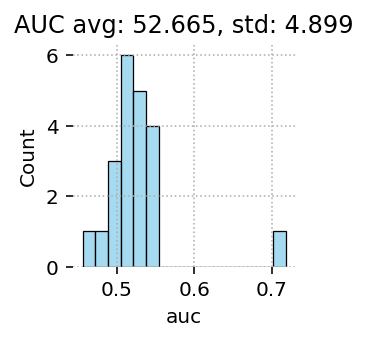

In [52]:
log = f"AUC avg: {auc_df['auc'].mean()*100:.3f}, std: {auc_df['auc'].std()*100:.3f}"
plt.figure(figsize=(2,2))
sns.histplot(auc_df['auc'], color='skyblue')
plt.title(log)
print(f"{auc_df['auc'].mean()*100:.2f}+-{auc_df['auc'].std()*100:.2f}")
# print(f"{dementia_auc_df['auc'].mean()*100:.2f}+-{dementia_auc_df['auc'].std()*100:.2f}")

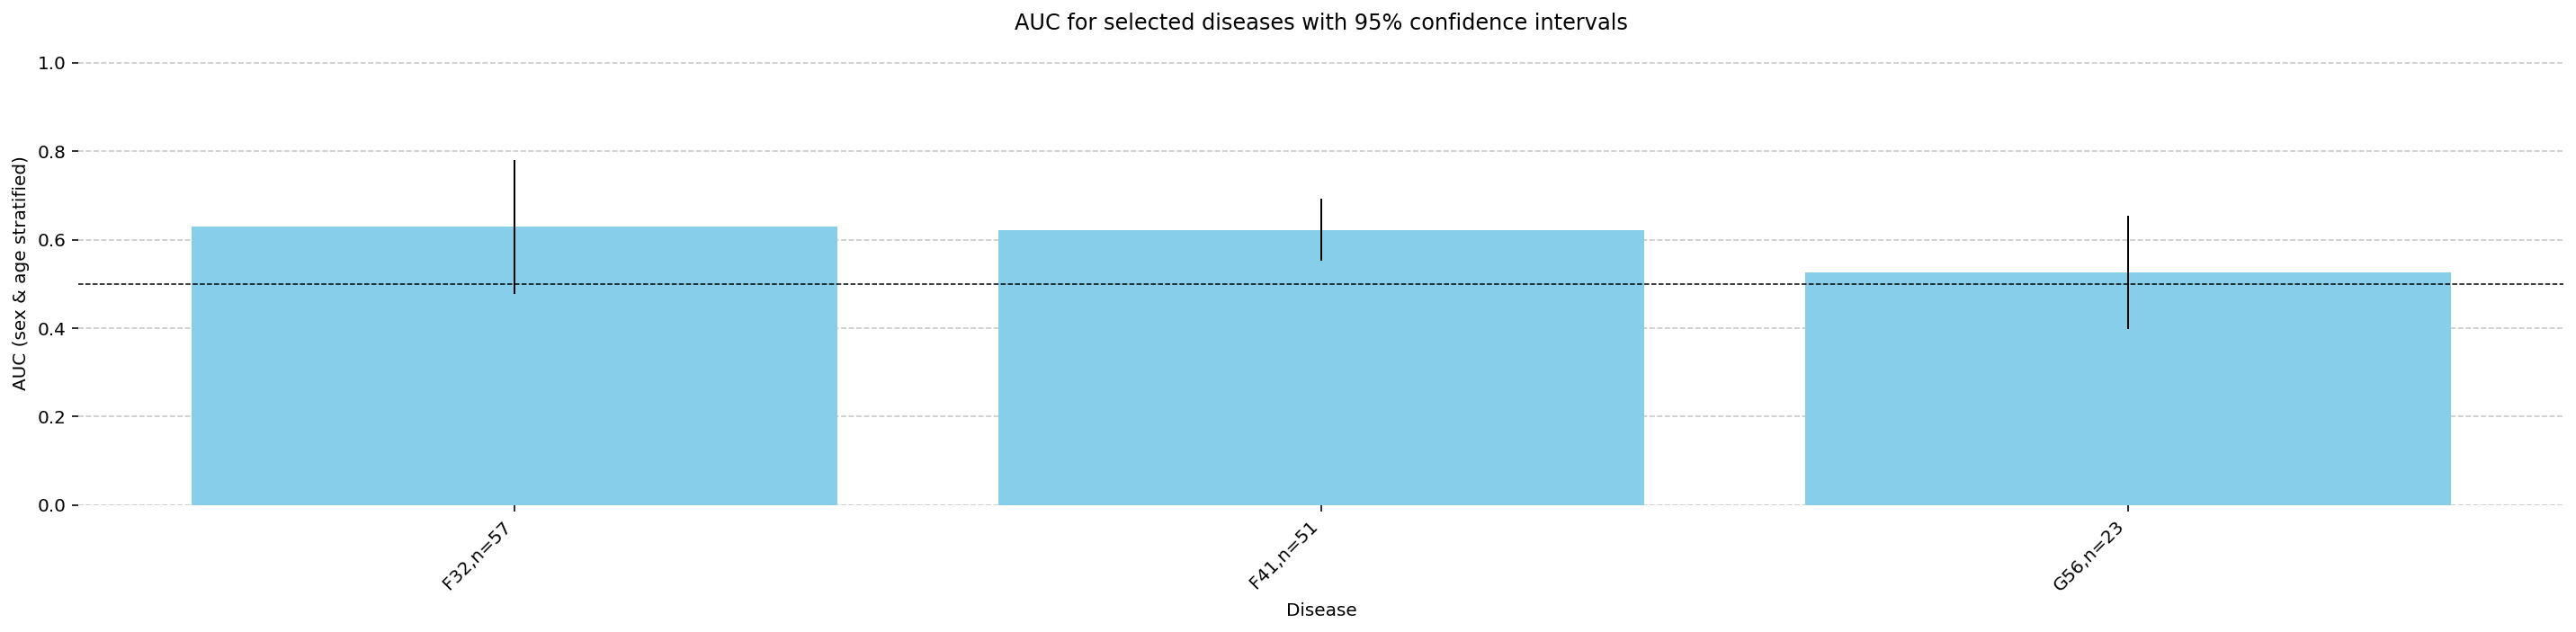

In [113]:
dementia_auc_df = dementia_auc_df.sort_values(by='n_diseased', ascending=False)
plt.figure(figsize=(20, 5))

# Create the bar chart
bars = plt.bar(range(len(dementia_auc_df)), dementia_auc_df['auc'], color='skyblue')

plt.errorbar(
    range(len(dementia_auc_df)), 
    dementia_auc_df['auc'], 
    yerr=1.96 * np.sqrt(dementia_auc_df['auc_variance_delong']),
    fmt='none', 
    color='black', 
    capsize=0,
    linewidth=1.0,
)

# Add labels and title
plt.xlabel('Disease')
plt.ylabel('AUC (sex & age stratified)')
plt.title('AUC for selected diseases with 95% confidence intervals')
plt.xticks(range(len(dementia_auc_df)), dementia_auc_df['name']+',n='+dementia_auc_df['n_diseased'].astype(int).astype(str), rotation=45, ha='right')
plt.gca().set_axisbelow(True)
plt.grid(axis='x', visible=False)
plt.axhline(0.5, color='k', linestyle='--', linewidth=0.75)
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

## BrainGnn

In [53]:
from models import brain_gnn


class GraphNet(nn.Module):
    def __init__(self, in_channel, out_channel, hid_channel=768, **kwargs) -> None:
        super().__init__()
        self.node_sz = 116
        self.net = brain_gnn.Network(node_sz=self.node_sz, in_channel=in_channel, out_channel=hid_channel, hidden_size=hid_channel, nlayer=2)
        self.pooled_node_sz = math.ceil(self.node_sz*self.net.ratio*self.net.ratio)
        self.lin_node = nn.Linear(self.pooled_node_sz, 1)
        self.lin_out = nn.Linear(hid_channel, out_channel)

    def forward(self, batch):
        x = self.net(batch)
        x = torch.stack(x[0].split(self.pooled_node_sz)).permute(0, 2, 1)
        x = self.lin_node(x)[..., 0]
        return self.lin_out(x)

def multiclass_eval(i, classifier, device, loader, return_pred=False):
    classifier.eval()
    y_true = []
    y_pred = []
    y_scores = []
    losses = []
    loss_fn = nn.CrossEntropyLoss()
    
    for batch in loader:
        gt = batch['y'][:, i].to(device)
        with torch.no_grad():
            y = classifier(batch.to(device)) 
            loss = loss_fn(y.float(), gt.long())
        if return_pred:
            y_scores.append(y.detach().cpu())
            y_pred.append(y.argmax(1).detach().cpu())
            y_true.append(gt.detach().cpu())
        losses.append(loss.detach().cpu().item())

    if return_pred:
        y_true = torch.cat(y_true, dim = 0).detach().cpu().numpy()
        y_pred = torch.cat(y_pred, dim = 0).detach().cpu().numpy()
        y_scores = torch.cat(y_scores, dim = 0).detach().cpu().numpy()
        return np.mean(losses), y_true, y_pred, y_scores
    else:
        return np.mean(losses)


### eval AUC

In [54]:
mi = 0
model = GraphNet(in_channel=xs[0].shape[1], out_channel=2)
model.load_state_dict(torch.load(f'baseline_BrainGNN-grouped_out/ckpt_{vocab_grouped[mi]}.ckpt', weights_only=False)['ckpt'])
model = model.to(device)
_, gt, preds, scores = multiclass_eval(mi, model, device, val_batches, return_pred=True)

In [55]:
gt.shape, scores.shape, len(val_idx)

((1322,), (1322, 2), 1322)

In [56]:
case = np_softmax(scores)[(gt==1), 1]
control = np_softmax(scores)[(gt==0), 1]
get_auc_delong_var(control, case)

(0.5597718, 0.0007654671391733415)

In [57]:

all_aucs = []
# for mi in trange(len(vocab_grouped)):
for mi in tqdm(pos_ratio.argsort()[-100:]):
    model = GraphNet(in_channel=xs[0].shape[1], out_channel=2)
    model.load_state_dict(torch.load(f'baseline_BrainGNN-grouped_out/ckpt_{vocab_grouped[mi]}.ckpt', weights_only=False)['ckpt'])    # if model is None: continue
    model = model.to(device)
    assert isinstance(model, nn.Module)
    _, gt, preds, scores = multiclass_eval(mi, model, device, val_batches, return_pred=True)
    scores = np_softmax(scores)
    model.cpu()
    age = ages[val_idx, mi]
    control_ages_max = all_control_ages_max[:, mi]
    control_ages_min = all_control_ages_min[:, mi]
    for i, aa in enumerate(age_groups):
        case = scores[(age >= aa) & (age < aa + age_step) & (gt==1)]
        control = scores[((control_ages_max >= aa) & (control_ages_max < aa + age_step)) | \
            ((control_ages_min >= aa) & (control_ages_min < aa + age_step)) & \
            (gt==0)]
        control = control[:, 1]
        case = case[:, 1]
        if len(control) == 0 or len(case) == 0:
            continue
        
        auc_value_delong, auc_variance_delong = get_auc_delong_var(control, case)
        auc_delong_dict = {"auc_delong": auc_value_delong, "auc_variance_delong": auc_variance_delong}

        out_item = {
            "token": mi,
            "name": vocab_grouped[mi],
            "auc": auc_value_delong,
            "age": aa,
            "n_healthy": len(control),
            "n_diseased": len(case),
            "case_score": case,
            "control_score": control,
        }
        all_aucs.append(out_item | auc_delong_dict)
        


 14%|██████                                      | 3/22 [00:06<00:41,  2.16s/it]/tmp/ipykernel_7932/3540653806.py:67: RuntimeWarning: Degrees of freedom <= 0 for slice
  sx = np.cov(v01)
/ram/USERS/ziquanw/softwares/miniconda3/envs/flashattn3/lib/python3.12/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/ram/USERS/ziquanw/softwares/miniconda3/envs/flashattn3/lib/python3.12/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
100%|███████████████████████████████████████████| 22/22 [00:38<00:00,  1.76s/it]


In [58]:
auc_df_all_brackets = pd.DataFrame(all_aucs)
auc_df = auc_df_all_brackets.groupby(['token']).apply(aggregate_normals, include_groups=False).reset_index()
auc_df['name'] = np.array(vocab_grouped)[auc_df['token']]
auc_df['n'] = auc_df['n_diseased']+auc_df['n_healthy']
auc_df = auc_df.sort_values(by='name', ascending=False)
auc_df_all_brackets.to_csv('mia-exp_eval_out/auc_df_age-separate_BrainGNN-grouped.csv')
auc_df.to_csv('mia-exp_eval_out/auc_df_age-grouped_BrainGNN-grouped.csv')
auc_df_dict['BrainGNN'] = auc_df
# dementia_auc_df = auc_df[auc_df['name'].map(lambda x: x[0] in ['F', 'G'])]
print(auc_df)

    token       auc  auc_variance_delong  n_groups  n_diseased  n_healthy  \
20     21  0.572460             0.003047       6.0        33.0     1581.0   
19     20  0.505790             0.000058       8.0       654.0     1388.0   
18     19  0.526901             0.000779       8.0       195.0     1727.0   
17     18  0.518970             0.001020       8.0       556.0     1473.0   
16     17  0.507137             0.002129       6.0        21.0     1720.0   
15     15  0.567460             0.173759       1.0         2.0      252.0   
14     14  0.479621             0.000677       8.0       181.0     1733.0   
13     13  0.501832             0.000749       8.0       367.0     1602.0   
12     12  0.526663             0.000531       8.0       443.0     1534.0   
11     11  0.558366             0.000876       8.0       155.0     1744.0   
10     10  0.512898             0.000130       8.0       615.0     1393.0   
9       9  0.511625             0.000676       8.0       209.0     1719.0   

51.99+-3.72


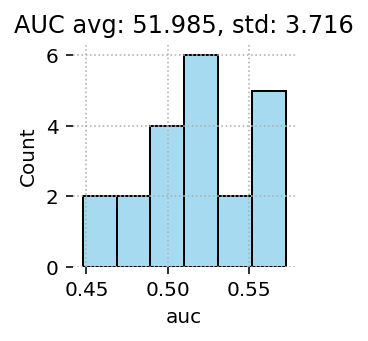

In [59]:
log = f"AUC avg: {auc_df['auc'].mean()*100:.3f}, std: {auc_df['auc'].std()*100:.3f}"
plt.figure(figsize=(2,2))
sns.histplot(auc_df['auc'], color='skyblue')
plt.title(log)
print(f"{auc_df['auc'].mean()*100:.2f}+-{auc_df['auc'].std()*100:.2f}")
# print(f"{dementia_auc_df['auc'].mean()*100:.2f}+-{dementia_auc_df['auc'].std()*100:.2f}")

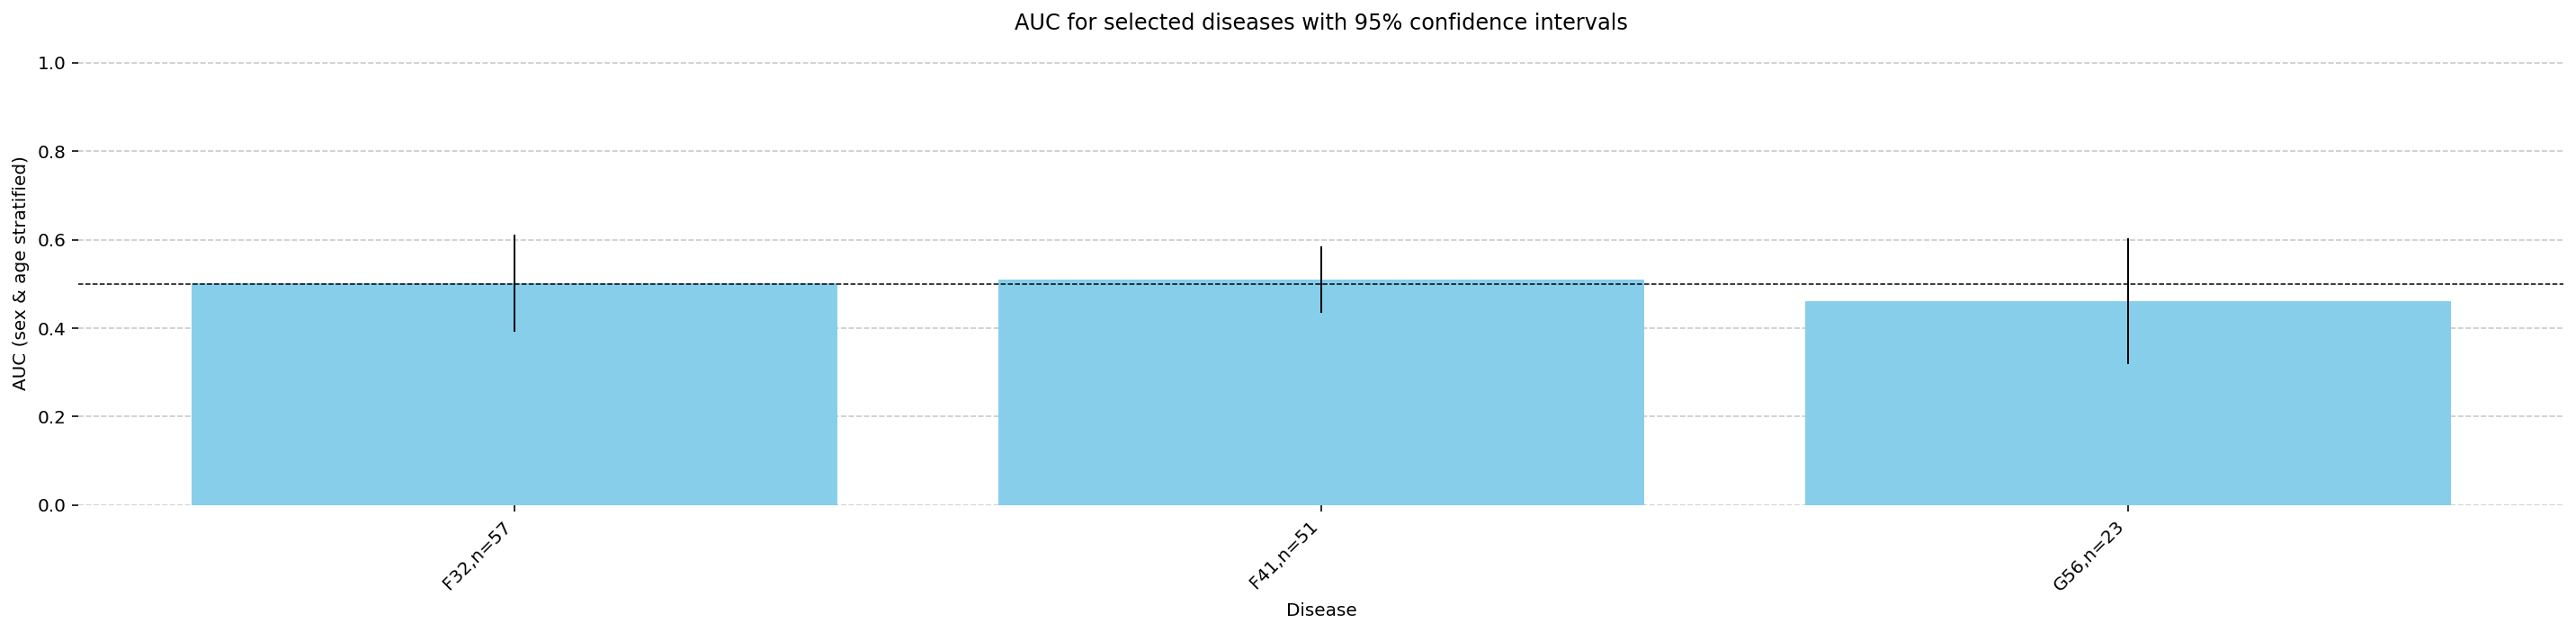

In [121]:
dementia_auc_df = dementia_auc_df.sort_values(by='n_diseased', ascending=False)
plt.figure(figsize=(20, 5))

# Create the bar chart
bars = plt.bar(range(len(dementia_auc_df)), dementia_auc_df['auc'], color='skyblue')

plt.errorbar(
    range(len(dementia_auc_df)), 
    dementia_auc_df['auc'], 
    yerr=1.96 * np.sqrt(dementia_auc_df['auc_variance_delong']),
    fmt='none', 
    color='black', 
    capsize=0,
    linewidth=1.0,
)

# Add labels and title
plt.xlabel('Disease')
plt.ylabel('AUC (sex & age stratified)')
plt.title('AUC for selected diseases with 95% confidence intervals')
plt.xticks(range(len(dementia_auc_df)), dementia_auc_df['name']+',n='+dementia_auc_df['n_diseased'].astype(int).astype(str), rotation=45, ha='right')
plt.gca().set_axisbelow(True)
plt.grid(axis='x', visible=False)
plt.axhline(0.5, color='k', linestyle='--', linewidth=0.75)
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

## BNT

In [60]:
from models import brain_net_transformer

class GraphNet(nn.Module):
    def __init__(self, in_channel, out_channel, hid_channel=768, **kwargs) -> None:
        super().__init__()
        self.node_sz = 116
        self.lin_in = nn.Linear(in_channel, hid_channel)
        self.net = brain_net_transformer.BrainNetworkTransformer(node_sz=self.node_sz, in_channel=in_channel, out_channel=hid_channel, hidden_size=hid_channel, nlayer=2)
        self.lin_node = nn.Linear(self.node_sz, 1)
        self.lin_out = nn.Linear(hid_channel, out_channel)

    def forward(self, batch):
        x = self.lin_in(batch['x'])
        x = self.net(batch)
        x = torch.stack(x.split(self.node_sz)).permute(0, 2, 1)
        x = self.lin_node(x)[..., 0]
        return self.lin_out(x)

def multiclass_eval(i, classifier, device, loader, return_pred=False):
    classifier.eval()
    y_true = []
    y_pred = []
    y_scores = []
    losses = []
    loss_fn = nn.CrossEntropyLoss()
    
    for batch in loader:
        gt = batch['y'][:, i].to(device)
        with torch.no_grad():
            y = classifier(batch.to(device)) 
            loss = loss_fn(y.float(), gt.long())
        if return_pred:
            y_scores.append(y.detach().cpu())
            y_pred.append(y.argmax(1).detach().cpu())
            y_true.append(gt.detach().cpu())
        losses.append(loss.detach().cpu().item())

    if return_pred:
        y_true = torch.cat(y_true, dim = 0).detach().cpu().numpy()
        y_pred = torch.cat(y_pred, dim = 0).detach().cpu().numpy()
        y_scores = torch.cat(y_scores, dim = 0).detach().cpu().numpy()
        return np.mean(losses), y_true, y_pred, y_scores
    else:
        return np.mean(losses)


### eval AUC

In [61]:
mi = 0
model = GraphNet(in_channel=xs[0].shape[1], out_channel=2)
model.load_state_dict(torch.load(f'baseline_BNT-grouped_out/ckpt_{vocab_grouped[mi]}.ckpt', weights_only=False)['ckpt'])
model = model.to(device)
_, gt, preds, scores = multiclass_eval(mi, model, device, val_batches, return_pred=True)

/ram/USERS/ziquanw/softwares/miniconda3/envs/flashattn3/lib/python3.12/site-packages/torch/nn/_reduction.py:51: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  warnings.warn(warning.format(ret))


In [62]:
gt.shape, scores.shape, len(val_idx)

((1322,), (1322, 2), 1322)

In [63]:
case = np_softmax(scores)[(gt==1), 1]
control = np_softmax(scores)[(gt==0), 1]
get_auc_delong_var(control, case)

(0.53878975, 0.0008261598015482166)

In [64]:
all_aucs = []
# for mi in trange(len(vocab_grouped)):
for mi in tqdm(pos_ratio.argsort()[-100:]):
    model = GraphNet(in_channel=xs[0].shape[1], out_channel=2)
    model.load_state_dict(torch.load(f'baseline_BNT-grouped_out/ckpt_{vocab_grouped[mi]}.ckpt', weights_only=False)['ckpt'])    # if model is None: continue
    model = model.to(device)
    assert isinstance(model, nn.Module)
    _, gt, preds, scores = multiclass_eval(mi, model, device, val_batches, return_pred=True)
    scores = np_softmax(scores)
    model.cpu()
    age = ages[val_idx, mi]
    control_ages_max = all_control_ages_max[:, mi]
    control_ages_min = all_control_ages_min[:, mi]
    for i, aa in enumerate(age_groups):
        case = scores[(age >= aa) & (age < aa + age_step) & (gt==1)]
        control = scores[((control_ages_max >= aa) & (control_ages_max < aa + age_step)) | \
            ((control_ages_min >= aa) & (control_ages_min < aa + age_step)) & \
            (gt==0)]
        control = control[:, 1]
        case = case[:, 1]
        if len(control) == 0 or len(case) == 0:
            continue
        
        auc_value_delong, auc_variance_delong = get_auc_delong_var(control, case)
        auc_delong_dict = {"auc_delong": auc_value_delong, "auc_variance_delong": auc_variance_delong}

        out_item = {
            "token": mi,
            "name": vocab_grouped[mi],
            "auc": auc_value_delong,
            "age": aa,
            "n_healthy": len(control),
            "n_diseased": len(case),
            "case_score": case,
            "control_score": control,
        }
        all_aucs.append(out_item | auc_delong_dict)
        


 14%|██████                                      | 3/22 [00:01<00:09,  1.94it/s]/tmp/ipykernel_7932/3540653806.py:67: RuntimeWarning: Degrees of freedom <= 0 for slice
  sx = np.cov(v01)
/ram/USERS/ziquanw/softwares/miniconda3/envs/flashattn3/lib/python3.12/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/ram/USERS/ziquanw/softwares/miniconda3/envs/flashattn3/lib/python3.12/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
100%|███████████████████████████████████████████| 22/22 [00:12<00:00,  1.79it/s]


In [65]:
auc_df_all_brackets = pd.DataFrame(all_aucs)
auc_df = auc_df_all_brackets.groupby(['token']).apply(aggregate_normals, include_groups=False).reset_index()
auc_df['name'] = np.array(vocab_grouped)[auc_df['token']]
auc_df['n'] = auc_df['n_diseased']+auc_df['n_healthy']
auc_df = auc_df.sort_values(by='name', ascending=False)
auc_df_all_brackets.to_csv('mia-exp_eval_out/auc_df_age-separate_BNT-grouped.csv')
auc_df.to_csv('mia-exp_eval_out/auc_df_age-grouped_BNT-grouped.csv')
auc_df_dict['BNT'] = auc_df
# dementia_auc_df = auc_df[auc_df['name'].map(lambda x: x[0] in ['F', 'G'])]
print(auc_df)

    token       auc  auc_variance_delong  n_groups  n_diseased  n_healthy  \
20     21  0.412964         2.865736e-03       6.0        33.0     1581.0   
19     20  0.500000         0.000000e+00       8.0       654.0     1388.0   
18     19  0.509653         7.269932e-04       8.0       195.0     1727.0   
17     18  0.500964         7.523063e-07       8.0       556.0     1473.0   
16     17  0.471041         5.118542e-03       6.0        21.0     1720.0   
15     15  0.948413         2.367639e-03       1.0         2.0      252.0   
14     14  0.499567         1.125578e-03       8.0       181.0     1733.0   
13     13  0.520342         8.891727e-04       8.0       367.0     1602.0   
12     12  0.509133         6.107519e-04       8.0       443.0     1534.0   
11     11  0.551504         1.207602e-03       8.0       155.0     1744.0   
10     10  0.540479         1.303052e-04       8.0       615.0     1393.0   
9       9  0.539344         1.358699e-03       8.0       209.0     1719.0   

52.69+-10.21


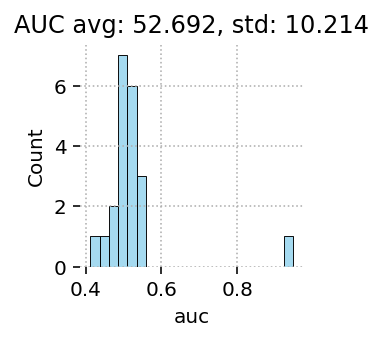

In [66]:
log = f"AUC avg: {auc_df['auc'].mean()*100:.3f}, std: {auc_df['auc'].std()*100:.3f}"
plt.figure(figsize=(2,2))
sns.histplot(auc_df['auc'], color='skyblue')
plt.title(log)
print(f"{auc_df['auc'].mean()*100:.2f}+-{auc_df['auc'].std()*100:.2f}")
# print(f"{dementia_auc_df['auc'].mean()*100:.2f}+-{dementia_auc_df['auc'].std()*100:.2f}")

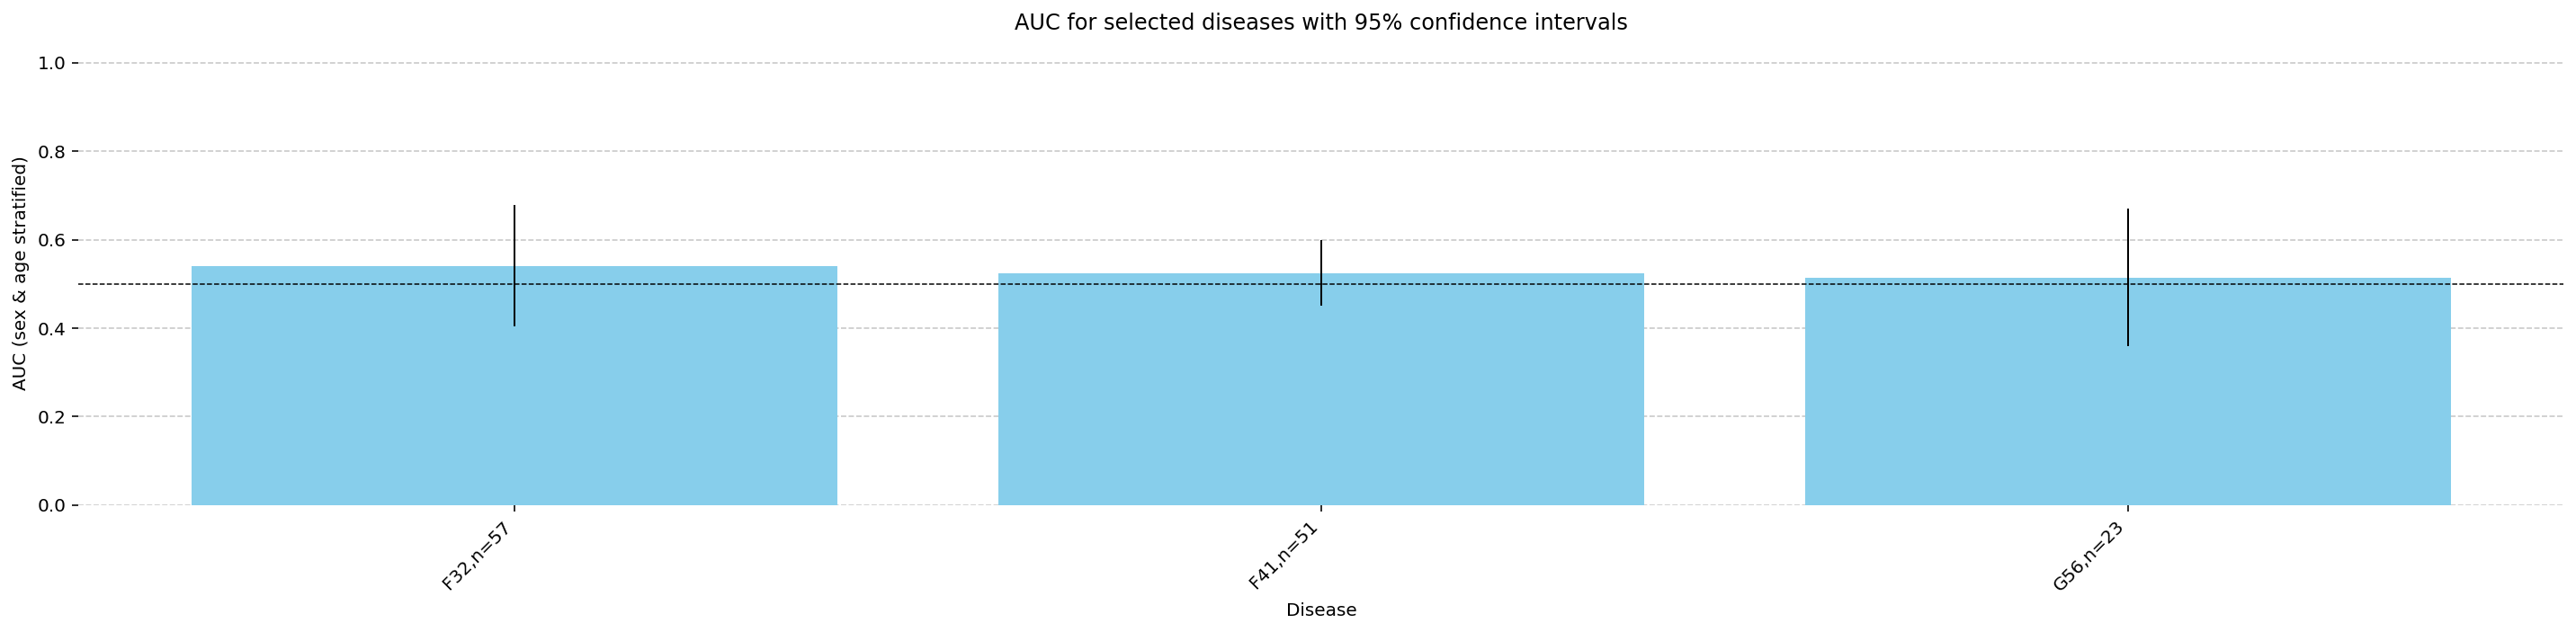

In [129]:
dementia_auc_df = dementia_auc_df.sort_values(by='n_diseased', ascending=False)
plt.figure(figsize=(20, 5))

# Create the bar chart
bars = plt.bar(range(len(dementia_auc_df)), dementia_auc_df['auc'], color='skyblue')

plt.errorbar(
    range(len(dementia_auc_df)), 
    dementia_auc_df['auc'], 
    yerr=1.96 * np.sqrt(dementia_auc_df['auc_variance_delong']),
    fmt='none', 
    color='black', 
    capsize=0,
    linewidth=1.0,
)

# Add labels and title
plt.xlabel('Disease')
plt.ylabel('AUC (sex & age stratified)')
plt.title('AUC for selected diseases with 95% confidence intervals')
plt.xticks(range(len(dementia_auc_df)), dementia_auc_df['name']+',n='+dementia_auc_df['n_diseased'].astype(int).astype(str), rotation=45, ha='right')
plt.gca().set_axisbelow(True)
plt.grid(axis='x', visible=False)
plt.axhline(0.5, color='k', linestyle='--', linewidth=0.75)
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

## BolT

In [67]:
from models import bolt


class GraphNet(nn.Module):
    def __init__(self, in_channel, out_channel, hid_channel=768, **kwargs) -> None:
        super().__init__()
        self.node_sz = 116
        self.net = bolt.get_BolT(node_sz=self.node_sz, in_channel=in_channel, out_channel=hid_channel, hidden_size=hid_channel, nlayer=2)
        self.lin_node = nn.Linear(self.node_sz, 1)
        self.lin_out = nn.Linear(hid_channel, out_channel)

    def forward(self, batch):
        x = self.net(batch)
        x = torch.stack(x.split(self.node_sz)).permute(0, 2, 1)
        x = self.lin_node(x)[..., 0]
        return self.lin_out(x)
        

def multiclass_eval(i, classifier, device, loader, return_pred=False):
    classifier.eval()
    y_true = []
    y_pred = []
    y_scores = []
    losses = []
    loss_fn = nn.CrossEntropyLoss()
    
    for batch in loader:
        gt = batch['y'][:, i].to(device)
        with torch.no_grad():
            y = classifier(batch.to(device)) 
            loss = loss_fn(y.float(), gt.long())
        if return_pred:
            y_scores.append(y.detach().cpu())
            y_pred.append(y.argmax(1).detach().cpu())
            y_true.append(gt.detach().cpu())
        losses.append(loss.detach().cpu().item())

    if return_pred:
        y_true = torch.cat(y_true, dim = 0).detach().cpu().numpy()
        y_pred = torch.cat(y_pred, dim = 0).detach().cpu().numpy()
        y_scores = torch.cat(y_scores, dim = 0).detach().cpu().numpy()
        return np.mean(losses), y_true, y_pred, y_scores
    else:
        return np.mean(losses)
     

/ram/USERS/ziquanw/softwares/miniconda3/envs/flashattn3/lib/python3.12/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


### eval AUC

In [68]:
mi = 0
model = GraphNet(in_channel=xs[0].shape[1], out_channel=2)
model.load_state_dict(torch.load(f'baseline_BolT-grouped_out/ckpt_{vocab_grouped[mi]}.ckpt', weights_only=False)['ckpt'])
model = model.to(device)
_, gt, preds, scores = multiclass_eval(mi, model, device, val_batches, return_pred=True)

In [69]:
gt.shape, scores.shape, len(val_idx)

((1322,), (1322, 2), 1322)

In [70]:
case = np_softmax(scores)[(gt==1), 1]
control = np_softmax(scores)[(gt==0), 1]
get_auc_delong_var(control, case)

(0.49658468, 0.0009797434359847146)

In [71]:
pos_ratio.argsort()[-100:]

array([16, 17, 21,  8, 15,  2,  0,  5,  6, 11, 14, 19,  7,  9,  3, 13,  1,
       12,  4, 18, 10, 20])

In [72]:
all_aucs = []
# for mi in trange(len(vocab_grouped)):
for mi in tqdm(pos_ratio.argsort()[-100:]):
    model = GraphNet(in_channel=xs[0].shape[1], out_channel=2)
    model.load_state_dict(torch.load(f'baseline_BolT-grouped_out/ckpt_{vocab_grouped[mi]}.ckpt', weights_only=False)['ckpt'])    # if model is None: continue
    model = model.to(device)
    assert isinstance(model, nn.Module)
    _, gt, preds, scores = multiclass_eval(mi, model, device, val_batches, return_pred=True)
    scores = np_softmax(scores)
    model.cpu()
    age = ages[val_idx, mi]
    control_ages_max = all_control_ages_max[:, mi]
    control_ages_min = all_control_ages_min[:, mi]
    for i, aa in enumerate(age_groups):
        case = scores[(age >= aa) & (age < aa + age_step) & (gt==1)]
        control = scores[((control_ages_max >= aa) & (control_ages_max < aa + age_step)) | \
            ((control_ages_min >= aa) & (control_ages_min < aa + age_step)) & \
            (gt==0)]
        control = control[:, 1]
        case = case[:, 1]
        if len(control) == 0 or len(case) == 0:
            continue
        
        auc_value_delong, auc_variance_delong = get_auc_delong_var(control, case)
        auc_delong_dict = {"auc_delong": auc_value_delong, "auc_variance_delong": auc_variance_delong}

        out_item = {
            "token": mi,
            "name": vocab_grouped[mi],
            "auc": auc_value_delong,
            "age": aa,
            "n_healthy": len(control),
            "n_diseased": len(case),
            "case_score": case,
            "control_score": control,
        }
        all_aucs.append(out_item | auc_delong_dict)
        


 14%|██████                                      | 3/22 [00:02<00:17,  1.11it/s]/tmp/ipykernel_7932/3540653806.py:67: RuntimeWarning: Degrees of freedom <= 0 for slice
  sx = np.cov(v01)
/ram/USERS/ziquanw/softwares/miniconda3/envs/flashattn3/lib/python3.12/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/ram/USERS/ziquanw/softwares/miniconda3/envs/flashattn3/lib/python3.12/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
100%|███████████████████████████████████████████| 22/22 [00:20<00:00,  1.09it/s]


In [73]:
auc_df_all_brackets = pd.DataFrame(all_aucs)
auc_df = auc_df_all_brackets.groupby(['token']).apply(aggregate_normals, include_groups=False).reset_index()
auc_df['name'] = np.array(vocab_grouped)[auc_df['token']]
auc_df['n'] = auc_df['n_diseased']+auc_df['n_healthy']
auc_df = auc_df.sort_values(by='name', ascending=False)
auc_df_all_brackets.to_csv('mia-exp_eval_out/auc_df_age-separate_BolT-grouped.csv')
auc_df.to_csv('mia-exp_eval_out/auc_df_age-grouped_BolT-grouped.csv')
auc_df_dict['BolT'] = auc_df
# dementia_auc_df = auc_df[auc_df['name'].map(lambda x: x[0] in ['F', 'G'])]
print(auc_df)

    token       auc  auc_variance_delong  n_groups  n_diseased  n_healthy  \
20     21  0.567783             0.003577       6.0        33.0     1581.0   
19     20  0.500000             0.000000       8.0       654.0     1388.0   
18     19  0.448967             0.000630       8.0       195.0     1727.0   
17     18  0.512164             0.000578       8.0       556.0     1473.0   
16     17  0.547442             0.004335       6.0        21.0     1720.0   
15     15  0.277778             0.022064       1.0         2.0      252.0   
14     14  0.552355             0.000871       8.0       181.0     1733.0   
13     13  0.522857             0.000516       8.0       367.0     1602.0   
12     12  0.479804             0.000563       8.0       443.0     1534.0   
11     11  0.503797             0.001494       8.0       155.0     1744.0   
10     10  0.501794             0.000010       8.0       615.0     1393.0   
9       9  0.515250             0.001103       8.0       209.0     1719.0   

49.28+-5.95


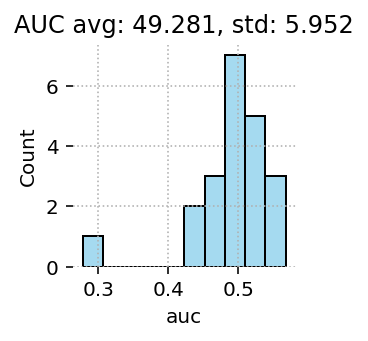

In [74]:
log = f"AUC avg: {auc_df['auc'].mean()*100:.3f}, std: {auc_df['auc'].std()*100:.3f}"
plt.figure(figsize=(2,2))
sns.histplot(auc_df['auc'], color='skyblue')
plt.title(log)
print(f"{auc_df['auc'].mean()*100:.2f}+-{auc_df['auc'].std()*100:.2f}")
# print(f"{dementia_auc_df['auc'].mean()*100:.2f}+-{dementia_auc_df['auc'].std()*100:.2f}")

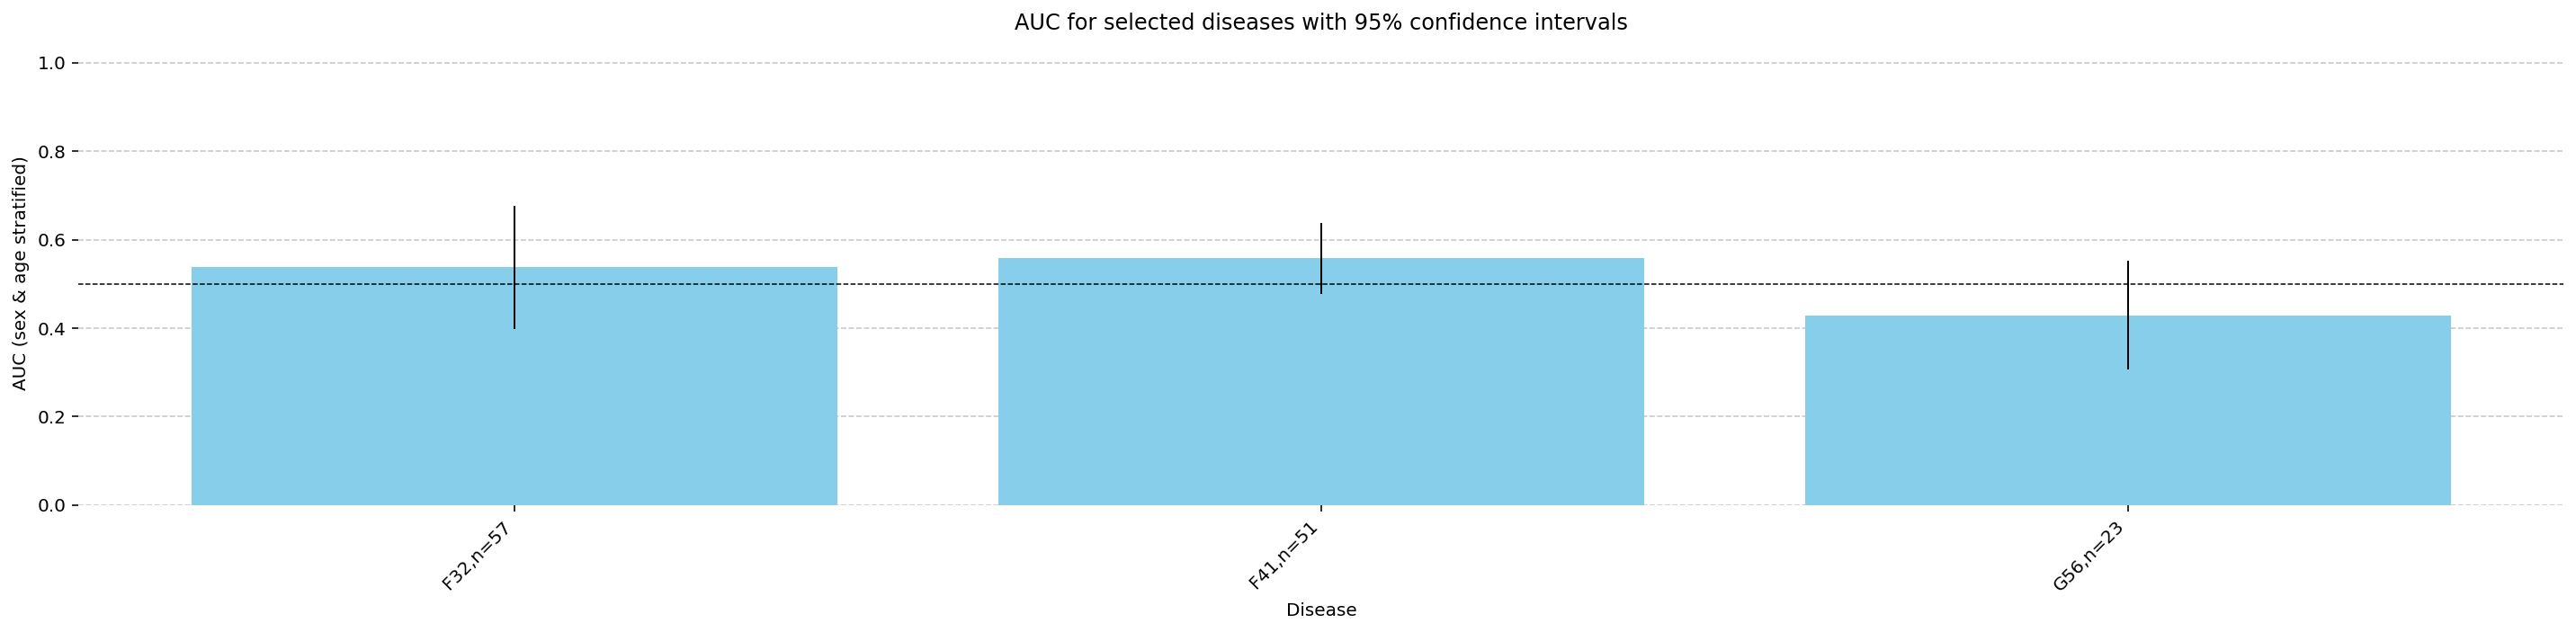

In [138]:
dementia_auc_df = dementia_auc_df.sort_values(by='n_diseased', ascending=False)
plt.figure(figsize=(20, 5))

# Create the bar chart
bars = plt.bar(range(len(dementia_auc_df)), dementia_auc_df['auc'], color='skyblue')

plt.errorbar(
    range(len(dementia_auc_df)), 
    dementia_auc_df['auc'], 
    yerr=1.96 * np.sqrt(dementia_auc_df['auc_variance_delong']),
    fmt='none', 
    color='black', 
    capsize=0,
    linewidth=1.0,
)

# Add labels and title
plt.xlabel('Disease')
plt.ylabel('AUC (sex & age stratified)')
plt.title('AUC for selected diseases with 95% confidence intervals')
plt.xticks(range(len(dementia_auc_df)), dementia_auc_df['name']+',n='+dementia_auc_df['n_diseased'].astype(int).astype(str), rotation=45, ha='right')
plt.gca().set_axisbelow(True)
plt.grid(axis='x', visible=False)
plt.axhline(0.5, color='k', linestyle='--', linewidth=0.75)
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

## Graphormer

In [75]:
from models import graphormer


class GraphNet(nn.Module):
    def __init__(self, in_channel, out_channel, hid_channel=768, **kwargs) -> None:
        super().__init__()
        self.node_sz = 116
        self.net = graphormer.Graphormer(node_sz=self.node_sz, in_channel=in_channel, out_channel=hid_channel, nlayer=4, heads=8)
        self.lin_node = nn.Linear(self.node_sz, 1)
        self.lin_out = nn.Linear(hid_channel, out_channel)

    def forward(self, batch):
        x = self.net(batch)
        x = torch.stack(x.split(self.node_sz)).permute(0, 2, 1)
        x = self.lin_node(x)[..., 0]
        return self.lin_out(x)

def multiclass_eval(i, classifier, device, loader, return_pred=False):
    classifier.eval()
    y_true = []
    y_pred = []
    y_scores = []
    losses = []
    loss_fn = nn.CrossEntropyLoss()
    
    for batch in loader:
        gt = batch['y'][:, i].to(device)
        with torch.no_grad():
            y = classifier(batch.to(device)) 
            loss = loss_fn(y.float(), gt.long())
        if return_pred:
            y_scores.append(y.detach().cpu())
            y_pred.append(y.argmax(1).detach().cpu())
            y_true.append(gt.detach().cpu())
        losses.append(loss.detach().cpu().item())

    if return_pred:
        y_true = torch.cat(y_true, dim = 0).detach().cpu().numpy()
        y_pred = torch.cat(y_pred, dim = 0).detach().cpu().numpy()
        y_scores = torch.cat(y_scores, dim = 0).detach().cpu().numpy()
        return np.mean(losses), y_true, y_pred, y_scores
    else:
        return np.mean(losses)
     

### eval AUC

In [76]:
mi = 0
model = GraphNet(in_channel=xs[0].shape[1], out_channel=2)
model.load_state_dict(torch.load(f'baseline_Graphormer-grouped_out/ckpt_{vocab_grouped[mi]}.ckpt', weights_only=False)['ckpt'])
model = model.to(device)
_, gt, preds, scores = multiclass_eval(mi, model, device, val_batches, return_pred=True)

In [77]:
gt.shape, scores.shape, len(val_idx)

((1322,), (1322, 2), 1322)

In [78]:
case = np_softmax(scores)[(gt==1), 1]
control = np_softmax(scores)[(gt==0), 1]
get_auc_delong_var(control, case)

(0.53718257, 0.0007963497148948433)

In [79]:
all_aucs = []
# for mi in trange(len(vocab_grouped)):
for mi in tqdm(pos_ratio.argsort()[-100:]):
    model = GraphNet(in_channel=xs[0].shape[1], out_channel=2)
    model.load_state_dict(torch.load(f'baseline_Graphormer-grouped_out/ckpt_{vocab_grouped[mi]}.ckpt', weights_only=False)['ckpt'])    # if model is None: continue
    model = model.to(device)
    assert isinstance(model, nn.Module)
    _, gt, preds, scores = multiclass_eval(mi, model, device, val_batches, return_pred=True)
    scores = np_softmax(scores)
    model.cpu()
    age = ages[val_idx, mi]
    control_ages_max = all_control_ages_max[:, mi]
    control_ages_min = all_control_ages_min[:, mi]
    for i, aa in enumerate(age_groups):
        case = scores[(age >= aa) & (age < aa + age_step) & (gt==1)]
        control = scores[((control_ages_max >= aa) & (control_ages_max < aa + age_step)) | \
            ((control_ages_min >= aa) & (control_ages_min < aa + age_step)) & \
            (gt==0)]
        control = control[:, 1]
        case = case[:, 1]
        if len(control) == 0 or len(case) == 0:
            continue
        
        auc_value_delong, auc_variance_delong = get_auc_delong_var(control, case)
        auc_delong_dict = {"auc_delong": auc_value_delong, "auc_variance_delong": auc_variance_delong}

        out_item = {
            "token": mi,
            "name": vocab_grouped[mi],
            "auc": auc_value_delong,
            "age": aa,
            "n_healthy": len(control),
            "n_diseased": len(case),
            "case_score": case,
            "control_score": control,
        }
        all_aucs.append(out_item | auc_delong_dict)
        


 14%|██████                                      | 3/22 [00:01<00:10,  1.88it/s]/tmp/ipykernel_7932/3540653806.py:67: RuntimeWarning: Degrees of freedom <= 0 for slice
  sx = np.cov(v01)
/ram/USERS/ziquanw/softwares/miniconda3/envs/flashattn3/lib/python3.12/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/ram/USERS/ziquanw/softwares/miniconda3/envs/flashattn3/lib/python3.12/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
100%|███████████████████████████████████████████| 22/22 [00:08<00:00,  2.53it/s]


In [80]:
auc_df_all_brackets = pd.DataFrame(all_aucs)
auc_df = auc_df_all_brackets.groupby(['token']).apply(aggregate_normals, include_groups=False).reset_index()
auc_df['name'] = np.array(vocab_grouped)[auc_df['token']]
auc_df['n'] = auc_df['n_diseased']+auc_df['n_healthy']
auc_df = auc_df.sort_values(by='name', ascending=False)
auc_df_all_brackets.to_csv('mia-exp_eval_out/auc_df_age-separate_Graphormer-grouped.csv')
auc_df.to_csv('mia-exp_eval_out/auc_df_age-grouped_Graphormer-grouped.csv')
auc_df_dict['Graphormer'] = auc_df
# dementia_auc_df = auc_df[auc_df['name'].map(lambda x: x[0] in ['F', 'G'])]
print(auc_df)

    token       auc  auc_variance_delong  n_groups  n_diseased  n_healthy  \
20     21  0.486299             0.003117       6.0        33.0     1581.0   
19     20  0.506517             0.000052       8.0       654.0     1388.0   
18     19  0.499408             0.001133       8.0       195.0     1727.0   
17     18  0.517672             0.000245       8.0       556.0     1473.0   
16     17  0.531011             0.004260       6.0        21.0     1720.0   
15     15  0.462302             0.002643       1.0         2.0      252.0   
14     14  0.479149             0.000911       8.0       181.0     1733.0   
13     13  0.498925             0.000771       8.0       367.0     1602.0   
12     12  0.483625             0.000575       8.0       443.0     1534.0   
11     11  0.512534             0.001343       8.0       155.0     1744.0   
10     10  0.533927             0.000425       8.0       615.0     1393.0   
9       9  0.483598             0.002146       8.0       209.0     1719.0   

50.33+-2.55


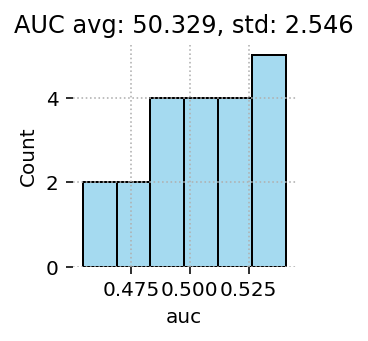

In [81]:
log = f"AUC avg: {auc_df['auc'].mean()*100:.3f}, std: {auc_df['auc'].std()*100:.3f}"
plt.figure(figsize=(2,2))
sns.histplot(auc_df['auc'], color='skyblue')
plt.title(log)
print(f"{auc_df['auc'].mean()*100:.2f}+-{auc_df['auc'].std()*100:.2f}")
# print(f"{dementia_auc_df['auc'].mean()*100:.2f}+-{dementia_auc_df['auc'].std()*100:.2f}")

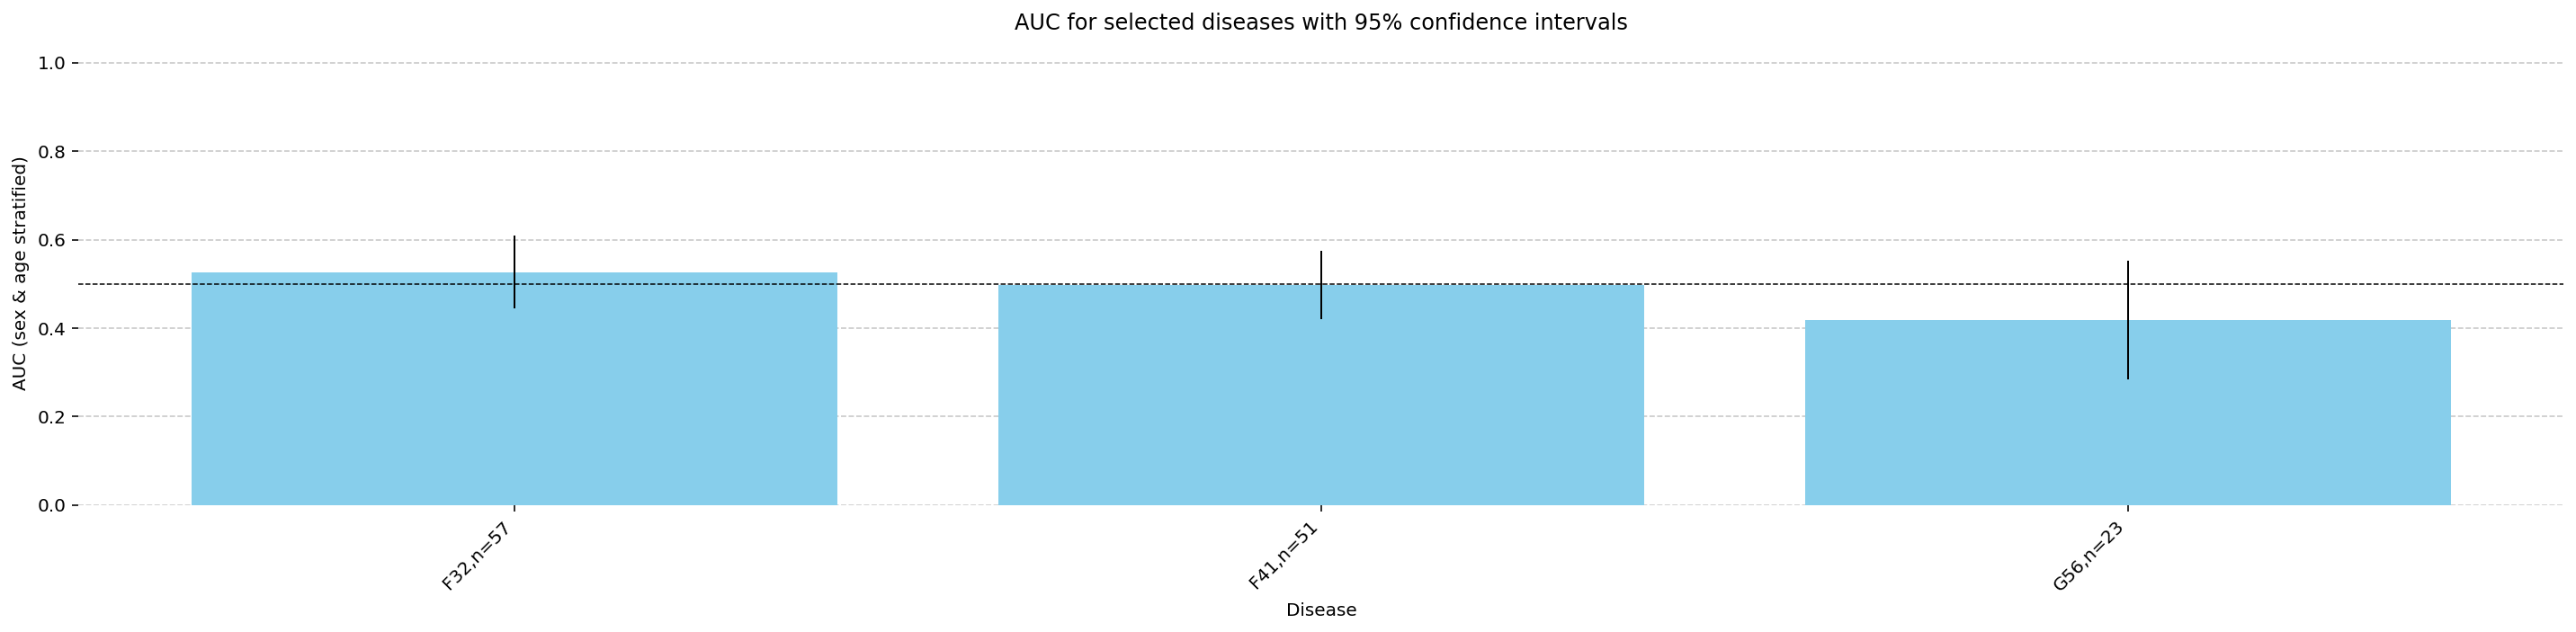

In [146]:
dementia_auc_df = dementia_auc_df.sort_values(by='n_diseased', ascending=False)
plt.figure(figsize=(20, 5))

# Create the bar chart
bars = plt.bar(range(len(dementia_auc_df)), dementia_auc_df['auc'], color='skyblue')

plt.errorbar(
    range(len(dementia_auc_df)), 
    dementia_auc_df['auc'], 
    yerr=1.96 * np.sqrt(dementia_auc_df['auc_variance_delong']),
    fmt='none', 
    color='black', 
    capsize=0,
    linewidth=1.0,
)

# Add labels and title
plt.xlabel('Disease')
plt.ylabel('AUC (sex & age stratified)')
plt.title('AUC for selected diseases with 95% confidence intervals')
plt.xticks(range(len(dementia_auc_df)), dementia_auc_df['name']+',n='+dementia_auc_df['n_diseased'].astype(int).astype(str), rotation=45, ha='right')
plt.gca().set_axisbelow(True)
plt.grid(axis='x', visible=False)
plt.axhline(0.5, color='k', linestyle='--', linewidth=0.75)
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

## NAGphormer

In [82]:
from models import nagphormer

class GraphNet(nn.Module):
    def __init__(self, in_channel, out_channel, hid_channel=768, **kwargs) -> None:
        super().__init__()
        self.node_sz = 116
        self.net = nagphormer.TransformerModel(node_sz=self.node_sz, in_channel=in_channel, out_channel=hid_channel, nlayer=4, heads=8)
        self.lin_node = nn.Linear(self.node_sz, 1)
        self.lin_out = nn.Linear(hid_channel, out_channel)

    def forward(self, batch):
        x = self.net(batch)
        x = torch.stack(x.split(self.node_sz)).permute(0, 2, 1)
        x = self.lin_node(x)[..., 0]
        return self.lin_out(x)

def multiclass_eval(i, classifier, device, loader, return_pred=False):
    classifier.eval()
    y_true = []
    y_pred = []
    y_scores = []
    losses = []
    loss_fn = nn.CrossEntropyLoss()
    
    for batch in loader:
        gt = batch['y'][:, i].to(device)
        with torch.no_grad():
            y = classifier(batch.to(device)) 
            loss = loss_fn(y.float(), gt.long())
        if return_pred:
            y_scores.append(y.detach().cpu())
            y_pred.append(y.argmax(1).detach().cpu())
            y_true.append(gt.detach().cpu())
        losses.append(loss.detach().cpu().item())

    if return_pred:
        y_true = torch.cat(y_true, dim = 0).detach().cpu().numpy()
        y_pred = torch.cat(y_pred, dim = 0).detach().cpu().numpy()
        y_scores = torch.cat(y_scores, dim = 0).detach().cpu().numpy()
        return np.mean(losses), y_true, y_pred, y_scores
    else:
        return np.mean(losses)
     

### eval AUC

In [83]:
mi = 0
model = GraphNet(in_channel=xs[0].shape[1], out_channel=2)
model.load_state_dict(torch.load(f'baseline_NAGphormer-grouped_out/ckpt_{vocab_grouped[mi]}.ckpt', weights_only=False)['ckpt'])
model = model.to(device)
_, gt, preds, scores = multiclass_eval(mi, model, device, val_batches, return_pred=True)

In [84]:
gt.shape, scores.shape, len(val_idx)

((1322,), (1322, 2), 1322)

In [85]:
case = np_softmax(scores)[(gt==1), 1]
control = np_softmax(scores)[(gt==0), 1]
get_auc_delong_var(control, case)

(0.43845224, 0.0008187974583851688)

In [86]:
all_aucs = []
# for mi in trange(len(vocab_grouped)):
for mi in tqdm(pos_ratio.argsort()[-100:]):
    model = GraphNet(in_channel=xs[0].shape[1], out_channel=2)
    model.load_state_dict(torch.load(f'baseline_NAGphormer-grouped_out/ckpt_{vocab_grouped[mi]}.ckpt', weights_only=False)['ckpt'])    # if model is None: continue
    model = model.to(device)
    assert isinstance(model, nn.Module)
    _, gt, preds, scores = multiclass_eval(mi, model, device, val_batches, return_pred=True)
    scores = np_softmax(scores)
    model.cpu()
    age = ages[val_idx, mi]
    control_ages_max = all_control_ages_max[:, mi]
    control_ages_min = all_control_ages_min[:, mi]
    for i, aa in enumerate(age_groups):
        case = scores[(age >= aa) & (age < aa + age_step) & (gt==1)]
        control = scores[((control_ages_max >= aa) & (control_ages_max < aa + age_step)) | \
            ((control_ages_min >= aa) & (control_ages_min < aa + age_step)) & \
            (gt==0)]
        control = control[:, 1]
        case = case[:, 1]
        if len(control) == 0 or len(case) == 0:
            continue
        
        auc_value_delong, auc_variance_delong = get_auc_delong_var(control, case)
        auc_delong_dict = {"auc_delong": auc_value_delong, "auc_variance_delong": auc_variance_delong}

        out_item = {
            "token": mi,
            "name": vocab_grouped[mi],
            "auc": auc_value_delong,
            "age": aa,
            "n_healthy": len(control),
            "n_diseased": len(case),
            "case_score": case,
            "control_score": control,
        }
        all_aucs.append(out_item | auc_delong_dict)
        


 14%|██████                                      | 3/22 [00:01<00:08,  2.26it/s]/tmp/ipykernel_7932/3540653806.py:67: RuntimeWarning: Degrees of freedom <= 0 for slice
  sx = np.cov(v01)
/ram/USERS/ziquanw/softwares/miniconda3/envs/flashattn3/lib/python3.12/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/ram/USERS/ziquanw/softwares/miniconda3/envs/flashattn3/lib/python3.12/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
100%|███████████████████████████████████████████| 22/22 [00:09<00:00,  2.31it/s]


In [87]:
auc_df_all_brackets = pd.DataFrame(all_aucs)
auc_df = auc_df_all_brackets.groupby(['token']).apply(aggregate_normals, include_groups=False).reset_index()
auc_df['name'] = np.array(vocab_grouped)[auc_df['token']]
auc_df['n'] = auc_df['n_diseased']+auc_df['n_healthy']
auc_df = auc_df.sort_values(by='name', ascending=False)
auc_df_all_brackets.to_csv('mia-exp_eval_out/auc_df_age-separate_NAGphormer-grouped.csv')
auc_df.to_csv('mia-exp_eval_out/auc_df_age-grouped_NAGphormer-grouped.csv')
auc_df_dict['NAGphormer'] = auc_df
# dementia_auc_df = auc_df[auc_df['name'].map(lambda x: x[0] in ['F', 'G'])]
print(auc_df)

    token       auc  auc_variance_delong  n_groups  n_diseased  n_healthy  \
20     21  0.527405             0.003809       6.0        33.0     1581.0   
19     20  0.500000             0.000000       8.0       654.0     1388.0   
18     19  0.503501             0.001212       8.0       195.0     1727.0   
17     18  0.499437             0.000646       8.0       556.0     1473.0   
16     17  0.401999             0.006729       6.0        21.0     1720.0   
15     15  0.246032             0.003298       1.0         2.0      252.0   
14     14  0.479428             0.000873       8.0       181.0     1733.0   
13     13  0.488327             0.001034       8.0       367.0     1602.0   
12     12  0.513226             0.000565       8.0       443.0     1534.0   
11     11  0.428908             0.001201       8.0       155.0     1744.0   
10     10  0.517785             0.000024       8.0       615.0     1393.0   
9       9  0.476861             0.001362       8.0       209.0     1719.0   

47.54+-6.34


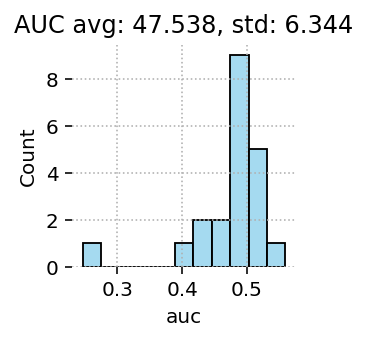

In [88]:
log = f"AUC avg: {auc_df['auc'].mean()*100:.3f}, std: {auc_df['auc'].std()*100:.3f}"
plt.figure(figsize=(2,2))
sns.histplot(auc_df['auc'], color='skyblue')
plt.title(log)
print(f"{auc_df['auc'].mean()*100:.2f}+-{auc_df['auc'].std()*100:.2f}")
# print(f"{dementia_auc_df['auc'].mean()*100:.2f}+-{dementia_auc_df['auc'].std()*100:.2f}")

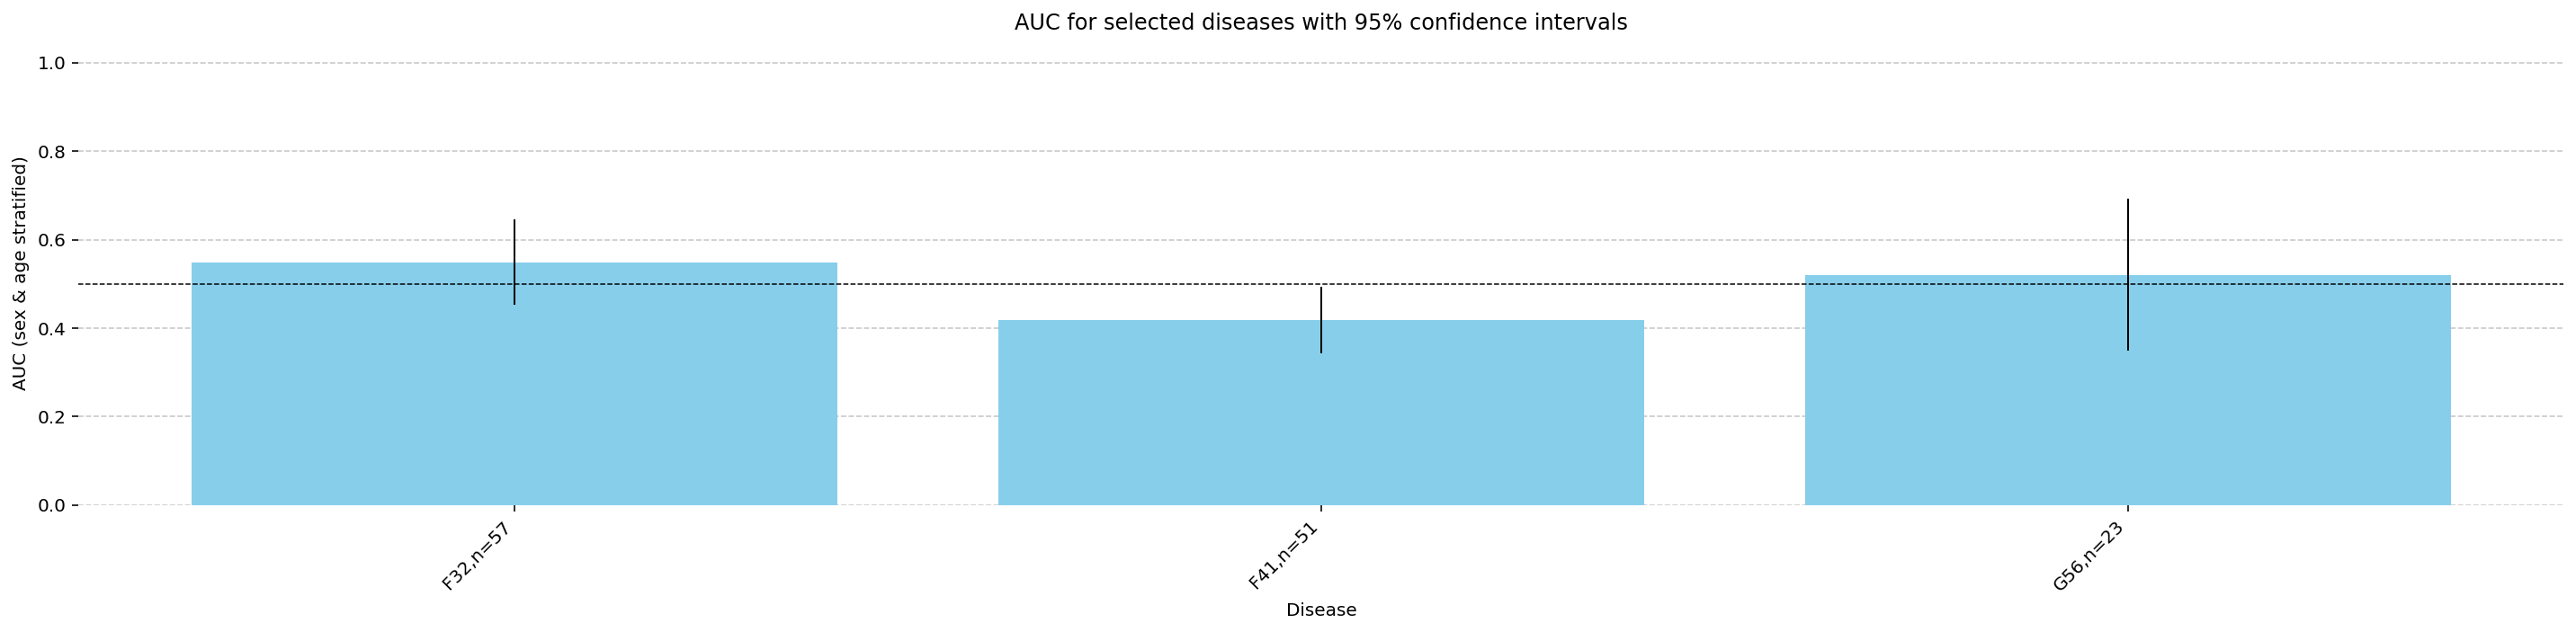

In [154]:
dementia_auc_df = dementia_auc_df.sort_values(by='n_diseased', ascending=False)
plt.figure(figsize=(20, 5))

# Create the bar chart
bars = plt.bar(range(len(dementia_auc_df)), dementia_auc_df['auc'], color='skyblue')

plt.errorbar(
    range(len(dementia_auc_df)), 
    dementia_auc_df['auc'], 
    yerr=1.96 * np.sqrt(dementia_auc_df['auc_variance_delong']),
    fmt='none', 
    color='black', 
    capsize=0,
    linewidth=1.0,
)

# Add labels and title
plt.xlabel('Disease')
plt.ylabel('AUC (sex & age stratified)')
plt.title('AUC for selected diseases with 95% confidence intervals')
plt.xticks(range(len(dementia_auc_df)), dementia_auc_df['name']+',n='+dementia_auc_df['n_diseased'].astype(int).astype(str), rotation=45, ha='right')
plt.gca().set_axisbelow(True)
plt.grid(axis='x', visible=False)
plt.axhline(0.5, color='k', linestyle='--', linewidth=0.75)
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

## NeuroDetour

In [117]:
from models import neuro_detour

class DetourTransformer(nn.Module):

    def __init__(self, 
        heads: int = 2,
        nlayer: int = 1,
        node_sz: int=116,
        in_channel = 10,
        out_channel: int = 10,
        concat: bool = False,
        dek: int = 4,
        pek: int = 10,
        dropout: float = 0.1,
        edge_dim = None,
        bias: bool = True,
        hiddim: int = 1024,
        detour_type = 'node',
        batch_size = 32,
        device='cuda:0',
        lconsist_w=1,
        *args, **kwargs) -> None:
        
        super(DetourTransformer, self).__init__()
        self.lconsist_w = lconsist_w
        org_in_channel = in_channel
        in_channel = out_channel
        if in_channel % heads != 0:
            in_channel = in_channel  + heads - (in_channel % heads)
        self.detour_type = detour_type
        self.nlayer = nlayer
        self.node_sz = node_sz
            
        self.lin_first = nn.Sequential(
            nn.Linear(org_in_channel, in_channel), 
            nn.BatchNorm1d(in_channel), 
            nn.LeakyReLU()
        )
        self.lin_in = nn.Sequential(
            nn.Linear(in_channel, out_channel), 
            nn.BatchNorm1d(out_channel), 
            nn.LeakyReLU(),
        )
        # self.net = torch.nn.TransformerEncoder(
        #     torch.nn.TransformerEncoderLayer(d_model=in_channel, nhead=heads, dim_feedforward=in_channel, dropout=dropout, batch_first=True),
        #     num_layers=nlayer,
        #     norm=None#nn.LayerNorm(in_channel)
        # )
        self.net = nn.ModuleList([torch.nn.TransformerEncoder(
            torch.nn.TransformerEncoderLayer(d_model=in_channel, nhead=heads, dim_feedforward=hiddim, dropout=dropout, batch_first=True),
            num_layers=1,
            norm=nn.LayerNorm(in_channel)#nn.LayerNorm(in_channel)# #nn.LayerNorm(in_channel) # None#
        ) for _ in range(nlayer)])
        self.net_fc = nn.ModuleList([torch.nn.TransformerEncoder(
            torch.nn.TransformerEncoderLayer(d_model=in_channel, nhead=heads, dim_feedforward=hiddim, dropout=dropout, batch_first=True),
            num_layers=1,
            norm=nn.LayerNorm(in_channel)#nn.LayerNorm(in_channel)# #nn.LayerNorm(in_channel) # None#
        ) for _ in range(nlayer)])
        self.heads = heads
        self.in_channel = in_channel
        self.out_channel = out_channel
        self.mask_heldout = torch.zeros(batch_size, node_sz, node_sz) - torch.inf
        self.mask_heldout = self.mask_heldout.to(device)
        self.fcsc_loss = nn.MSELoss()
        ###################################
        self.loss = 0
        ###################################

    def forward(self, data):
        self.loss = 0
        node_feature = data.x
        node_feature = self.lin_first(node_feature)
        node_feature = node_feature.view(data.batch.max()+1, len(torch.where(data.batch==0)[0]), self.in_channel)
        ###################################
        node_feature_fc = node_feature
        ###################################

        adj = data.adj_sc
        adj_fc = data.adj_fc
        org_adj = adj
        multi_mask = []
        for _ in range(self.heads):
            if self.mask_heldout.shape[1] != adj.shape[1]:
                self.mask_heldout = torch.zeros(self.mask_heldout.shape[0], adj.shape[1], adj.shape[2], device=adj.device) - torch.inf
            mask = self.mask_heldout[:len(adj)]
            mask[torch.logical_and(adj, adj_fc)] = 0
            adj = (adj.float() @ org_adj.float()) > 0
            multi_mask.append(mask)
        multi_mask = torch.cat(multi_mask)
        # multi_mask = multi_mask==0
        ### fmask(FC) #################################
        mask_fc = self.mask_heldout[:len(adj_fc)]
        mask_fc[adj_fc] = 0
        mask_fc = mask_fc.repeat(self.heads, 1, 1)
        # mask_fc = mask_fc==0
        ###############################################
        # for i in range(self.nlayer):
        #     node_feature = self.net[i](node_feature, mask=multi_mask) + node_feature
        # ## readout feature ############################
        #     node_feature_fc = self.net_fc[i](node_feature_fc, mask=mask_fc)
        #     self.loss = self.loss + self.lconsist_w*self.fcsc_loss(node_feature_fc, node_feature)
        # if not self.training:
        #     node_feature = node_feature_fc
        ###############################################
        return self.lin_in(node_feature.reshape(node_feature.shape[0] * node_feature.shape[1], self.in_channel))

class GraphNet(nn.Module):
    def __init__(self, in_channel, out_channel, hid_channel=512, **kwargs) -> None:
        super().__init__()
        self.node_sz = 116
        self.net = DetourTransformer(node_sz=self.node_sz, in_channel=in_channel, out_channel=hid_channel, hiddim=hid_channel, nlayer=2, heads=4, batch_size=batch_size, device=device)
        self.lin_node = nn.Linear(self.node_sz, 1)
        self.lin_out = nn.Linear(hid_channel, out_channel)

    def forward(self, batch):
        x = self.net(batch)
        x = torch.stack(x.split(self.node_sz)).permute(0, 2, 1)
        x = self.lin_node(x)[..., 0]
        return self.lin_out(x)
        
def multiclass_eval(i, classifier, device, loader, return_pred=False):
    classifier.eval()
    y_true = []
    y_pred = []
    y_scores = []
    losses = []
    loss_fn = nn.CrossEntropyLoss()
    
    for batch in loader:
        gt = batch['y'][:, i].to(device)
        with torch.no_grad():
            y = classifier(batch.to(device)) 
            loss = loss_fn(y.float(), gt.long())
        if return_pred:
            y_scores.append(y.detach().cpu())
            y_pred.append(y.argmax(1).detach().cpu())
            y_true.append(gt.detach().cpu())
        losses.append(loss.detach().cpu().item())

    if return_pred:
        y_true = torch.cat(y_true, dim = 0).detach().cpu().numpy()
        y_pred = torch.cat(y_pred, dim = 0).detach().cpu().numpy()
        y_scores = torch.cat(y_scores, dim = 0).detach().cpu().numpy()
        return np.mean(losses), y_true, y_pred, y_scores
    else:
        return np.mean(losses)
     

### eval AUC

In [118]:
batch_size = 32
mi = 18
model = GraphNet(in_channel=xs[0].shape[1], out_channel=2)
model.load_state_dict(torch.load(f'ICD_NeuroDetour-grouped_out/ckpt_{vocab_grouped[mi]}.ckpt', weights_only=False)['ckpt'])
model = model.to(device)
# first batch is nan for unknown reasons
_, gt, preds, scores = multiclass_eval(mi, model, device, [val_batches[0]]+val_batches, return_pred=True) 
gt = gt[batch_size:]
preds = preds[batch_size:]
scores = scores[batch_size:]

In [119]:
gt.shape, scores.shape, len(val_idx)

((1322,), (1322, 2), 1322)

In [120]:
case = np_softmax(scores)[(gt==1), 1]
control = np_softmax(scores)[(gt==0), 1]
get_auc_delong_var(control, case)

(0.4999633, 4.557334480255518e-06)

In [115]:
mi

18

In [121]:
all_aucs = []
# for mi in trange(len(vocab_grouped)):
for mi in tqdm(pos_ratio.argsort()[-100:]):
    # if mi != 18: continue
    model = GraphNet(in_channel=xs[0].shape[1], out_channel=2)
    model.load_state_dict(torch.load(f'ICD_NeuroDetour-grouped_out/ckpt_{vocab_grouped[mi]}.ckpt', weights_only=False)['ckpt'])    # if model is None: continue
    model = model.to(device)
    assert isinstance(model, nn.Module)
    _, gt, preds, scores = multiclass_eval(mi, model, device, [val_batches[0]]+val_batches, return_pred=True)
    gt = gt[batch_size:]
    preds = preds[batch_size:]
    scores = scores[batch_size:]
    scores = np_softmax(scores)
    model.cpu()
    age = ages[val_idx, mi]
    control_ages_max = all_control_ages_max[:, mi]
    control_ages_min = all_control_ages_min[:, mi]
    for i, aa in enumerate(age_groups):
        case = scores[(age >= aa) & (age < aa + age_step) & (gt==1)]
        control = scores[((control_ages_max >= aa) & (control_ages_max < aa + age_step)) | \
            ((control_ages_min >= aa) & (control_ages_min < aa + age_step)) & \
            (gt==0)]
        control = control[:, 1]
        case = case[:, 1]
        if len(control) == 0 or len(case) == 0:
            continue
        
        auc_value_delong, auc_variance_delong = get_auc_delong_var(control, case)
        auc_delong_dict = {"auc_delong": auc_value_delong, "auc_variance_delong": auc_variance_delong}

        out_item = {
            "token": mi,
            "name": vocab_grouped[mi],
            "auc": auc_value_delong,
            "age": aa,
            "n_healthy": len(control),
            "n_diseased": len(case),
            "case_score": case,
            "control_score": control,
        }
        all_aucs.append(out_item | auc_delong_dict)
        


100%|███████████████████████████████████████████| 22/22 [00:00<00:00, 57.76it/s]


In [122]:
auc_df_all_brackets = pd.DataFrame(all_aucs)
auc_df = auc_df_all_brackets.groupby(['token']).apply(aggregate_normals, include_groups=False).reset_index()
auc_df['name'] = np.array(vocab_grouped)[auc_df['token']]
auc_df['n'] = auc_df['n_diseased']+auc_df['n_healthy']
auc_df = auc_df.sort_values(by='name', ascending=False)
auc_df_all_brackets.to_csv('mia-exp_eval_out/auc_df_age-separate_NeuroDetour-grouped.csv')
auc_df.to_csv('mia-exp_eval_out/auc_df_age-grouped_NeuroDetour-grouped.csv')
auc_df_dict['NeuroDetour'] = auc_df
# dementia_auc_df = auc_df[auc_df['name'].map(lambda x: x[0] in ['F', 'G'])]
print(auc_df)

    token       auc  auc_variance_delong  n_groups  n_diseased  n_healthy  \
20     21  0.352119             0.001524       6.0        33.0     1581.0   
19     20  0.496953             0.000007       8.0       654.0     1388.0   
18     19  0.512258             0.000750       8.0       195.0     1727.0   
17     18  0.500043             0.000002       8.0       556.0     1473.0   
16     17  0.448469             0.003040       6.0        21.0     1720.0   
15     15  0.531746             0.084331       1.0         2.0      252.0   
14     14  0.493070             0.001325       8.0       181.0     1733.0   
13     13  0.503183             0.000818       8.0       367.0     1602.0   
12     12  0.501613             0.000637       8.0       443.0     1534.0   
11     11  0.525851             0.001515       8.0       155.0     1744.0   
10     10  0.500000             0.000000       8.0       615.0     1393.0   
9       9  0.466027             0.001191       8.0       209.0     1719.0   

50.32+-5.35


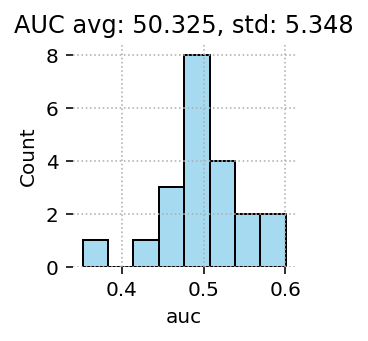

In [123]:
import seaborn as sns
log = f"AUC avg: {auc_df['auc'].mean()*100:.3f}, std: {auc_df['auc'].std()*100:.3f}"
plt.figure(figsize=(2,2))
sns.histplot(auc_df['auc'], color='skyblue')
plt.title(log)
print(f"{auc_df['auc'].mean()*100:.2f}+-{auc_df['auc'].std()*100:.2f}")
# print(f"{dementia_auc_df['auc'].mean()*100:.2f}+-{dementia_auc_df['auc'].std()*100:.2f}")

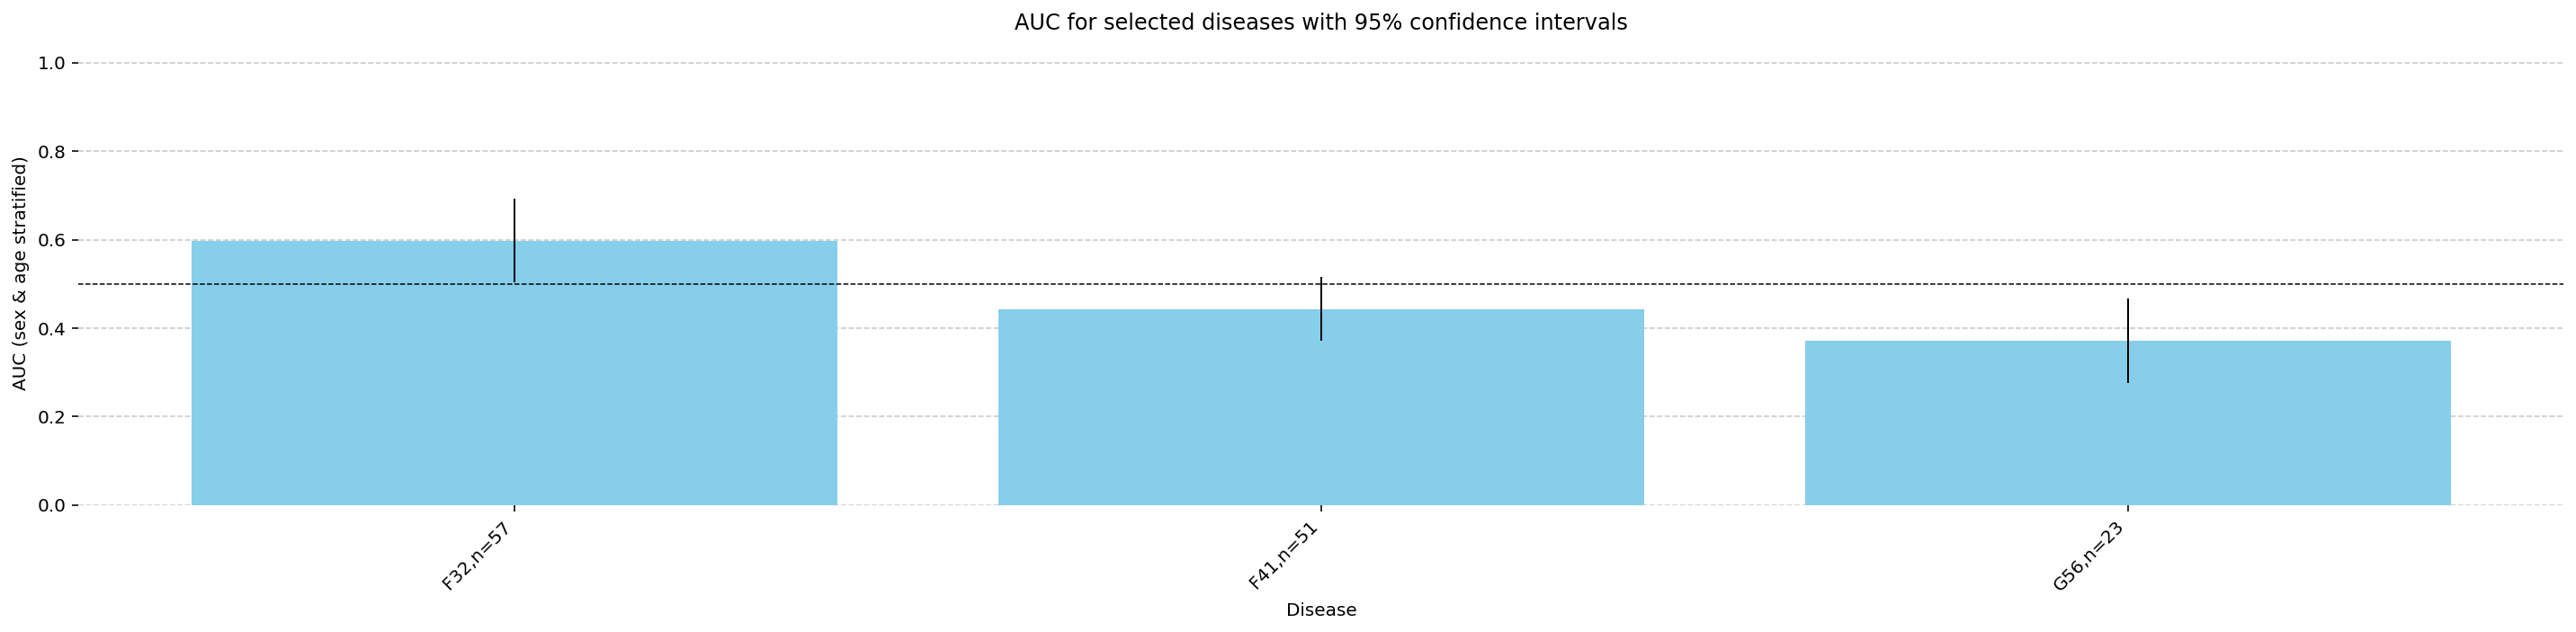

In [188]:
dementia_auc_df = dementia_auc_df.sort_values(by='n_diseased', ascending=False)
plt.figure(figsize=(20, 5))

# Create the bar chart
bars = plt.bar(range(len(dementia_auc_df)), dementia_auc_df['auc'], color='skyblue')

plt.errorbar(
    range(len(dementia_auc_df)), 
    dementia_auc_df['auc'], 
    yerr=1.96 * np.sqrt(dementia_auc_df['auc_variance_delong']),
    fmt='none', 
    color='black', 
    capsize=0,
    linewidth=1.0,
)

# Add labels and title
plt.xlabel('Disease')
plt.ylabel('AUC (sex & age stratified)')
plt.title('AUC for selected diseases with 95% confidence intervals')
plt.xticks(range(len(dementia_auc_df)), dementia_auc_df['name']+',n='+dementia_auc_df['n_diseased'].astype(int).astype(str), rotation=45, ha='right')
plt.gca().set_axisbelow(True)
plt.grid(axis='x', visible=False)
plt.axhline(0.5, color='k', linestyle='--', linewidth=0.75)
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

### NeuroDetourV2

In [259]:

class DetourTransformer(nn.Module):

    def __init__(self, 
        heads: int = 2,
        nlayer: int = 1,
        node_sz: int=116,
        in_channel = 10,
        out_channel: int = 10,
        dropout: float = 0.1,
        hiddim: int = 1024,
        batch_size = 32,
        device='cuda:0',
        lconsist_w=1,
        *args, **kwargs) -> None:
        
        super(DetourTransformer, self).__init__()
        self.lconsist_w = lconsist_w
        org_in_channel = in_channel
        # in_channel = out_channel
        if in_channel % heads != 0:
            in_channel = in_channel  + heads - (in_channel % heads)
        self.nlayer = nlayer
        self.node_sz = node_sz
            
        self.lin_first = nn.Sequential(
            nn.Linear(org_in_channel, in_channel), 
            nn.BatchNorm1d(in_channel), 
            nn.LeakyReLU()
        )
        self.lin_in = nn.Sequential(
            nn.Linear(in_channel, out_channel), 
            nn.BatchNorm1d(out_channel), 
            nn.LeakyReLU(),
        )
        # self.net = torch.nn.TransformerEncoder(
        #     torch.nn.TransformerEncoderLayer(d_model=in_channel, nhead=heads, dim_feedforward=in_channel, dropout=dropout, batch_first=True),
        #     num_layers=nlayer,
        #     norm=None#nn.LayerNorm(in_channel)
        # )
        self.net = nn.ModuleList([torch.nn.TransformerEncoder(
            torch.nn.TransformerEncoderLayer(d_model=in_channel, nhead=heads, dim_feedforward=hiddim, dropout=dropout, batch_first=True),
            num_layers=1,
            norm=None# #nn.LayerNorm(in_channel) # None#
        ) for _ in range(nlayer)])
        self.net_fc = nn.ModuleList([torch.nn.TransformerEncoder(
            torch.nn.TransformerEncoderLayer(d_model=in_channel, nhead=heads, dim_feedforward=hiddim, dropout=dropout, batch_first=True),
            num_layers=1,
            norm=None# #nn.LayerNorm(in_channel) # None#
        ) for _ in range(nlayer)])
        self.heads = heads
        self.in_channel = in_channel
        self.out_channel = out_channel
        self.mask_heldout = torch.zeros(batch_size, node_sz, node_sz) - torch.inf
        self.mask_heldout = self.mask_heldout.to(device)
        self.fcsc_loss = nn.MSELoss()
        ###################################
        self.loss = 0
        ###################################

    def forward(self, data):
        self.loss = 0
        node_feature = data.x
        node_feature = self.lin_first(node_feature)
        node_feature = node_feature.view(data.batch.max()+1, len(torch.where(data.batch==0)[0]), self.in_channel)
        ###################################
        node_feature_fc = node_feature
        ###################################

        adj = data.adj_sc
        adj_fc = data.adj_fc
        org_adj = adj
        multi_mask = []
        for _ in range(self.heads):
            if self.mask_heldout.shape[1] != adj.shape[1]:
                self.mask_heldout = torch.zeros(self.mask_heldout.shape[0], adj.shape[1], adj.shape[2], device=adj.device) - torch.inf
            mask = self.mask_heldout[:len(adj)]
            mask[torch.logical_and(adj, adj_fc)] = 0
            adj = (adj.float() @ org_adj.float()) > 0
            multi_mask.append(mask)
        multi_mask = torch.cat(multi_mask)
        # multi_mask = multi_mask==0
        ### fmask(FC) #################################
        mask_fc = self.mask_heldout[:len(adj_fc)]
        mask_fc[adj_fc] = 0
        mask_fc = mask_fc.repeat(self.heads, 1, 1)
        # mask_fc = mask_fc==0
        ###############################################
        for i in range(self.nlayer):
            node_feature = self.net[i](node_feature, mask=multi_mask) + node_feature
        ## readout feature ############################
            node_feature_fc = self.net_fc[i](node_feature_fc, mask=mask_fc)
            self.loss = self.loss + self.lconsist_w*self.fcsc_loss(node_feature_fc, node_feature)
        if not self.training:
            node_feature = node_feature_fc
        ###############################################
        return self.lin_in(node_feature.reshape(node_feature.shape[0] * node_feature.shape[1], self.in_channel))


class GraphNet(nn.Module):
    def __init__(self, in_channel, out_channel, hid_channel=768, **kwargs) -> None:
        super().__init__()
        self.node_sz = 116
        self.net = DetourTransformer(node_sz=self.node_sz, in_channel=in_channel, out_channel=hid_channel, hiddim=hid_channel, nlayer=4, heads=8, batch_size=batch_size, device=device)
        self.lin_node = nn.Linear(self.node_sz, 1)
        self.lin_out = nn.Linear(hid_channel, out_channel)

    def forward(self, batch):
        x = self.net(batch)
        x = torch.stack(x.split(self.node_sz)).permute(0, 2, 1)
        x = self.lin_node(x)[..., 0]
        return self.lin_out(x)

        


#### eval AUC

In [260]:
batch_size = 32
mi = 432
model = GraphNet(in_channel=xs[0].shape[1], out_channel=2)
model.load_state_dict(torch.load(f'ICD_NeuroDetourLR5e-3noLN_out/ckpt_{vocab_grouped[mi]}.ckpt', weights_only=False)['ckpt'])
model = model.to(device)
# first batch is nan for unknown reasons
_, gt, preds, scores = multiclass_eval(mi, model, device, [val_batches[0]]+val_batches, return_pred=True) 
gt = gt[batch_size:]
preds = preds[batch_size:]
scores = scores[batch_size:]

In [261]:
gt.shape, scores.shape, len(val_idx)

((1322,), (1322, 2), 1322)

In [264]:
case = np_softmax(scores)[(gt==1), 1]
control = np_softmax(scores)[(gt==0), 1]
get_auc_delong_var(control, case)

(0.48013887, 0.00032066529418432803)

In [265]:
all_aucs = []
# for mi in trange(len(vocab_grouped)):
for mi in tqdm(pos_ratio.argsort()[-100:]):
    model = GraphNet(in_channel=xs[0].shape[1], out_channel=2)
    model.load_state_dict(torch.load(f'ICD_NeuroDetourLR5e-3noLN_out/ckpt_{vocab_grouped[mi]}.ckpt', weights_only=False)['ckpt'])    # if model is None: continue
    model = model.to(device)
    assert isinstance(model, nn.Module)
    _, gt, preds, scores = multiclass_eval(mi, model, device, [val_batches[0]]+val_batches, return_pred=True)
    gt = gt[batch_size:]
    preds = preds[batch_size:]
    scores = scores[batch_size:]
    scores = np_softmax(scores)
    model.cpu()
    age = ages[val_idx, mi]
    control_ages_max = all_control_ages_max[:, mi]
    control_ages_min = all_control_ages_min[:, mi]
    for i, aa in enumerate(age_groups):
        case = scores[(age >= aa) & (age < aa + age_step) & (gt==1)]
        control = scores[((control_ages_max >= aa) & (control_ages_max < aa + age_step)) | \
            ((control_ages_min >= aa) & (control_ages_min < aa + age_step)) & \
            (gt==0)]
        control = control[:, 1]
        case = case[:, 1]
        if len(control) == 0 or len(case) == 0:
            continue
        
        auc_value_delong, auc_variance_delong = get_auc_delong_var(control, case)
        auc_delong_dict = {"auc_delong": auc_value_delong, "auc_variance_delong": auc_variance_delong}

        out_item = {
            "token": mi,
            "name": vocab_grouped[mi],
            "auc": auc_value_delong,
            "age": aa,
            "n_healthy": len(control),
            "n_diseased": len(case),
            "case_score": case,
            "control_score": control,
        }
        all_aucs.append(out_item | auc_delong_dict)
        


  1%|█▌                                                                                                                                                                | 1/100 [00:00<00:30,  3.22it/s]/tmp/ipykernel_814775/3540653806.py:67: RuntimeWarning: Degrees of freedom <= 0 for slice
  sx = np.cov(v01)
/ram/USERS/ziquanw/softwares/miniconda3/envs/flashattn3/lib/python3.12/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/ram/USERS/ziquanw/softwares/miniconda3/envs/flashattn3/lib/python3.12/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:28<00:00,  3.46it/s]


In [266]:
auc_df_all_brackets = pd.DataFrame(all_aucs)
auc_df = auc_df_all_brackets.groupby(['token']).apply(aggregate_normals, include_groups=False).reset_index()
auc_df['name'] = np.array(vocab_grouped)[auc_df['token']]
auc_df['n'] = auc_df['n_diseased']+auc_df['n_healthy']
auc_df = auc_df.sort_values(by='name', ascending=False)
auc_df_all_brackets.to_csv('mia-exp_eval_out/auc_df_age-separate_NeuroDetourV2.csv')
auc_df.to_csv('mia-exp_eval_out/auc_df_age-grouped_NeuroDetourV2.csv')
auc_df_dict['NeuroDetour'] = auc_df
dementia_auc_df = auc_df[auc_df['name'].map(lambda x: x[0] in ['F', 'G'])]
print(auc_df)

    token       auc  auc_variance_delong  n_groups  n_diseased  n_healthy  \
97   1433  0.476634             0.001634       6.0        79.0     1234.0   
96   1429  0.531597             0.001091       8.0       152.0     1786.0   
95   1428  0.504890             0.003040       7.0        41.0     1857.0   
94   1427  0.533497             0.001111       7.0        75.0     1841.0   
93   1425  0.480199             0.000828       7.0       110.0     1818.0   
..    ...       ...                  ...       ...         ...        ...   
4     154  0.491642             0.002249       8.0        88.0     1842.0   
3     113  0.543884             0.005491       6.0        47.0     1252.0   
2     105  0.474284             0.000877       7.0        52.0     1855.0   
1     100  0.437840             0.001310       7.0        64.0     1832.0   
0       6  0.542985             0.002569       7.0        36.0     1872.0   

   name       n  
97  Z96  1313.0  
96  Z92  1938.0  
95  Z91  1898.0  
94 

50.70+-4.99
51.53+-3.60


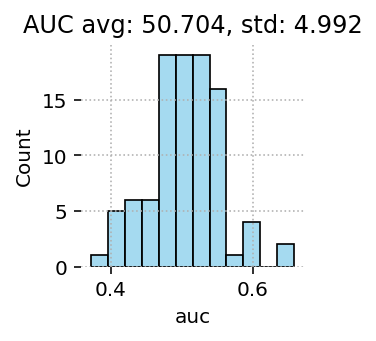

In [267]:
import seaborn as sns
log = f"AUC avg: {auc_df['auc'].mean()*100:.3f}, std: {auc_df['auc'].std()*100:.3f}"
plt.figure(figsize=(2,2))
sns.histplot(auc_df['auc'], color='skyblue')
plt.title(log)
print(f"{auc_df['auc'].mean()*100:.2f}+-{auc_df['auc'].std()*100:.2f}")
print(f"{dementia_auc_df['auc'].mean()*100:.2f}+-{dementia_auc_df['auc'].std()*100:.2f}")

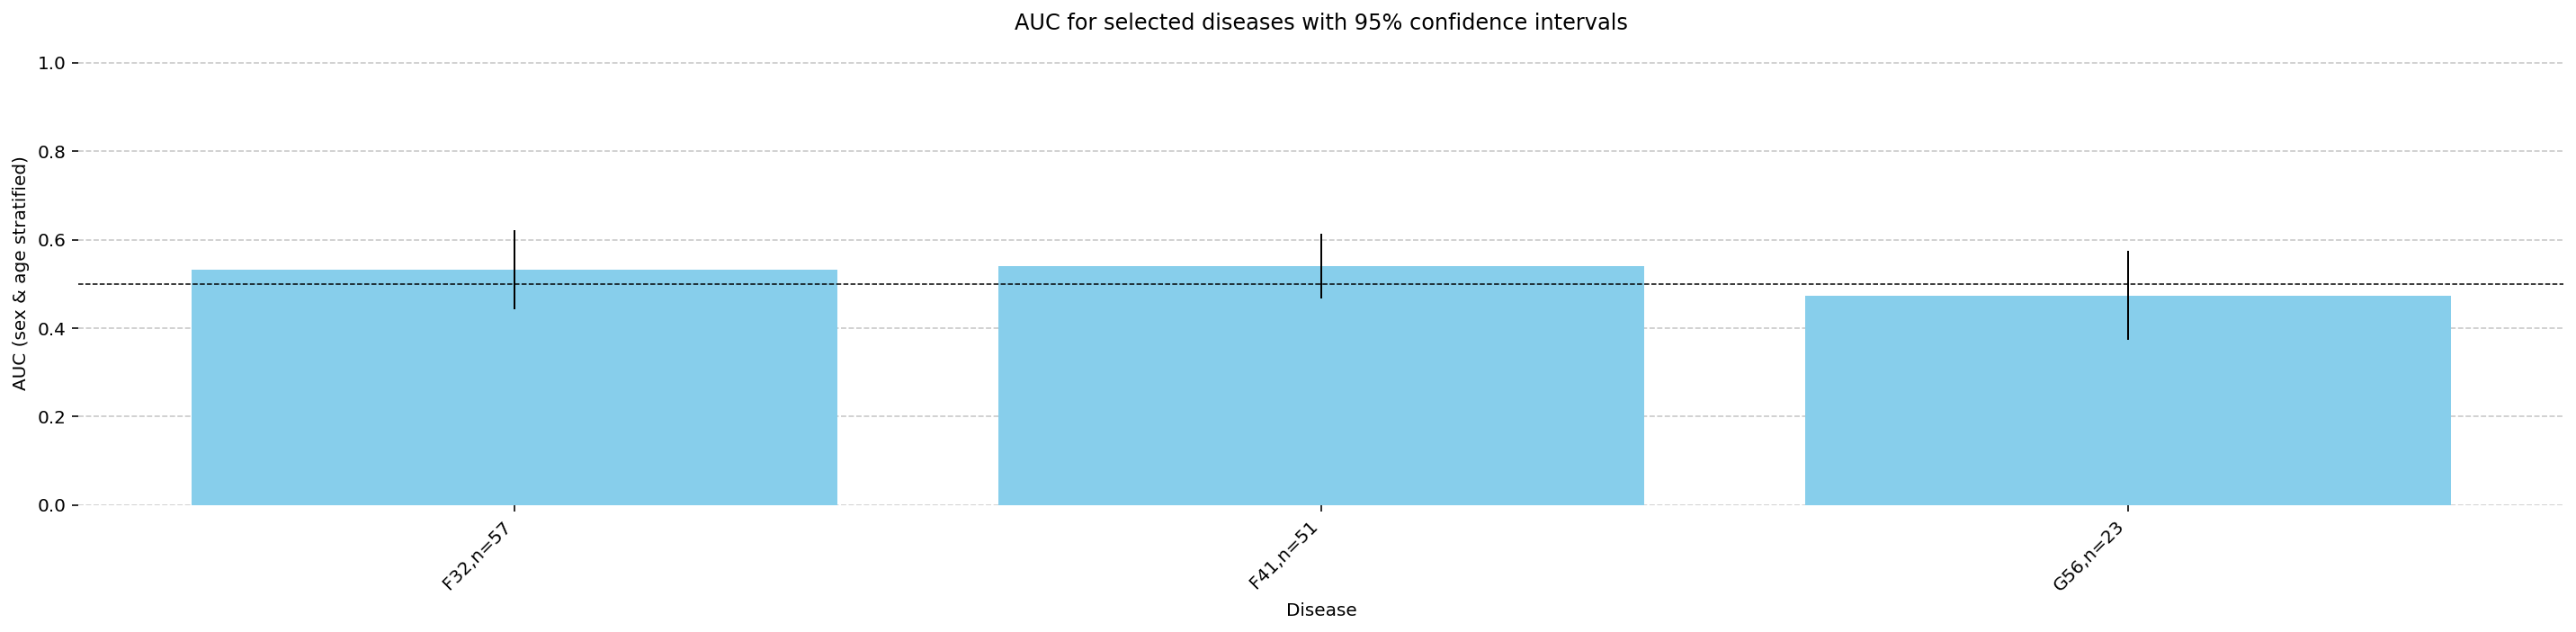

In [268]:
dementia_auc_df = dementia_auc_df.sort_values(by='n_diseased', ascending=False)
plt.figure(figsize=(20, 5))

# Create the bar chart
bars = plt.bar(range(len(dementia_auc_df)), dementia_auc_df['auc'], color='skyblue')

plt.errorbar(
    range(len(dementia_auc_df)), 
    dementia_auc_df['auc'], 
    yerr=1.96 * np.sqrt(dementia_auc_df['auc_variance_delong']),
    fmt='none', 
    color='black', 
    capsize=0,
    linewidth=1.0,
)

# Add labels and title
plt.xlabel('Disease')
plt.ylabel('AUC (sex & age stratified)')
plt.title('AUC for selected diseases with 95% confidence intervals')
plt.xticks(range(len(dementia_auc_df)), dementia_auc_df['name']+',n='+dementia_auc_df['n_diseased'].astype(int).astype(str), rotation=45, ha='right')
plt.gca().set_axisbelow(True)
plt.grid(axis='x', visible=False)
plt.axhline(0.5, color='k', linestyle='--', linewidth=0.75)
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

## Plot losses

In [215]:
auc_df_dict.keys()

dict_keys(['MLP', 'BrainGNN', 'GCN', 'BNT', 'BolT', 'Graphormer', 'NAGphormer', 'NeuroDetour'])

In [243]:
(multiclass_labels.sum(0)*-1).argsort()[:26]

array([ 432, 1423,  595,  253, 1429, 1424,  576, 1425,  587,  954,  569,
        952, 1422,  600,  528, 1398,  963,  601,  384,  154,  485, 1427,
        385,  697,  442,  695])

In [226]:
((multiclass_labels.sum(0)/multiclass_labels.shape[0])>0.1).sum()

4

In [228]:
pos_num = multiclass_labels.sum(0)
pos_num.sort()
pos_num

array([   0.,    0.,    0., ...,  861., 1310., 1550.])

In [238]:
pos_num[-26:] / multiclass_labels.shape[0]

array([0.05096506, 0.05134351, 0.05172196, 0.05197427, 0.05336193,
       0.05462344, 0.05525419, 0.05588495, 0.05790337, 0.06004794,
       0.06231866, 0.06887852, 0.07379841, 0.07392456, 0.07909676,
       0.07922291, 0.08351205, 0.08439511, 0.08843194, 0.09309953,
       0.09865018, 0.09877633, 0.10293932, 0.10861612, 0.16525798,
       0.19553425])

In [1]:
# fig, axes = plt.subplots(len(auc_df_dict)-1, 1, figsize=(2*(len(auc_df_dict)-1),2))
# custom_bins = np.logspace(-7, 0, 100)
i = 0
for k in auc_df_dict:
    if k == 'NeuroDetour': continue
    val_loss, last_loss = [], []
    for mi in (multiclass_labels.sum(0)*-1).argsort()[:4]:
    # for mi in trange(len(vocab_grouped), desc=k):
    # for mi in tqdm((multiclass_labels.sum(0)*-1).argsort(), desc=k):
        out = torch.load(f'baseline_{k}-grouped_out/ckpt_{vocab_grouped[mi]}.ckpt', weights_only=False)
        val_loss.append(out['best_loss'])
        last_loss.append(out['last_val_loss'])
    print(k, np.mean(val_loss), np.std(val_loss), val_loss)
    # sns.histplot(val_loss, bins=custom_bins, ax = axes[i])
    # axes[i].set_xscale('log')
    # axes[i].set_title(k)
    i += 1

NameError: name 'auc_df_dict' is not defined

In [27]:
print('\t'.join(chapters))
print('\t\t'.join([f'{pos_ratio[vocab_grouped.tolist().index(c)]:.5f}' for c in chapters]))

Chapter-XVIII	Chapter-VII	Chapter-XXI	Chapter-XI	Chapter-IV	Chapter-XIX	Chapter-XIV	Chapter-XII	Chapter-X	Chapter-XIII	Chapter-II	Chapter-IX	Chapter-VI	Chapter-XX
0.39763		0.14772		0.53425		0.45011		0.21509		0.13940		0.26227		0.12716		0.15744		0.31210		0.26858		0.33014		0.10319		0.14419


In [61]:
import os
chapters = None
for k in ['MLP', 'GCN', 'BrainGNN', 'BolT', 'BNT', 'Graphormer', 'NAGphormer', 'NeuroDetour']:
    val_loss, last_loss = [], []
    if chapters is None:
        chapters = [fn.split('_')[1][:-5] for fn in os.listdir(f'baseline_{k}-grouped_out')]
        chapters = [c for c in chapters if pos_ratio[vocab_grouped.tolist().index(c)] > 0.1]
    for chapter in chapters:
        outr = f"baseline_{k}-grouped_out" if k != 'NeuroDetour' else "ICD_NeuroDetour-grouped_out"
        # if not os.path.exists(f'{outr}/ckpt_{chapter}.ckpt'): continue
        out = torch.load(f'{outr}/ckpt_{chapter}.ckpt', weights_only=False)
        val_loss.append(out['best_loss'])
        last_loss.append(out['last_val_loss'])
    info = f"{k} {np.mean(val_loss):.5f}+-{np.std(val_loss):.5f}"
    for c, l in zip(chapters, val_loss):
        info += f'\t {c} \t {l:.5f}'
    print(info)

MLP 0.58442+-0.10185	 Chapter-XVIII 	 0.69208	 Chapter-VII 	 0.50000	 Chapter-XXI 	 0.67974	 Chapter-XI 	 0.68872	 Chapter-IV 	 0.64551	 Chapter-XIX 	 0.48044	 Chapter-XIV 	 0.68389	 Chapter-XII 	 0.45278	 Chapter-X 	 0.48535	 Chapter-XIII 	 0.66182	 Chapter-II 	 0.62731	 Chapter-IX 	 0.68065	 Chapter-VI 	 0.41497	 Chapter-XX 	 0.48866
GCN 0.56810+-0.10257	 Chapter-XVIII 	 0.69309	 Chapter-VII 	 0.48819	 Chapter-XXI 	 0.66664	 Chapter-XI 	 0.69002	 Chapter-IV 	 0.54858	 Chapter-XIX 	 0.46541	 Chapter-XIV 	 0.63910	 Chapter-XII 	 0.43600	 Chapter-X 	 0.48590	 Chapter-XIII 	 0.66025	 Chapter-II 	 0.62598	 Chapter-IX 	 0.67781	 Chapter-VI 	 0.40014	 Chapter-XX 	 0.47625
BrainGNN 0.59389+-0.09601	 Chapter-XVIII 	 0.69502	 Chapter-VII 	 0.47090	 Chapter-XXI 	 0.68673	 Chapter-XI 	 0.69412	 Chapter-IV 	 0.52410	 Chapter-XIX 	 0.46533	 Chapter-XIV 	 0.63110	 Chapter-XII 	 0.62666	 Chapter-X 	 0.47639	 Chapter-XIII 	 0.67334	 Chapter-II 	 0.61641	 Chapter-IX 	 0.69808	 Chapter-VI 	 0.42558	 Ch

In [263]:
vocab_grouped[(multiclass_labels.sum(0)*-1).argsort()[:4]]

array(['I10', 'Z86', 'K57', 'E78'], dtype='<U3')

In [80]:

val_loss, last_loss = [], []
# for mi in range(len(vocab_grouped)):
for mi in (multiclass_labels.sum(0)*-1).argsort()[:4]:
    out = torch.load(f'ICD_NeuroDetour_out/ckpt_{vocab_grouped[mi]}.ckpt', weights_only=False)
    val_loss.append(out['best_loss'])
    last_loss.append(out['last_val_loss'])
print('NeuroDetour', np.mean(val_loss), np.std(val_loss), val_loss)


NeuroDetour 0.4457133710384369 0.07648264015276256 [0.5419682264328003, 0.4850577414035797, 0.4190952181816101, 0.33673229813575745]


In [247]:
# fig, axes = plt.subplots(len(auc_df_dict)-1, 1, figsize=(2*(len(auc_df_dict)-1),2))
# custom_bins = np.logspace(-7, 0, 100)
i = 0
for k in auc_df_dict:
    if k == 'NeuroDetour': continue
    val_loss, last_loss = [], []
    for mi in (multiclass_labels.sum(0)*-1).argsort()[:26]:
    # for mi in trange(len(vocab_grouped), desc=k):
    # for mi in tqdm((multiclass_labels.sum(0)*-1).argsort(), desc=k):
        out = torch.load(f'baseline_{k}_out/ckpt_{vocab_grouped[mi]}.ckpt', weights_only=False)
        val_loss.append(out['best_loss'])
        last_loss.append(out['last_val_loss'])
    print(k, np.mean(val_loss), np.std(val_loss))
    # sns.histplot(val_loss, bins=custom_bins, ax = axes[i])
    # axes[i].set_xscale('log')
    # axes[i].set_title(k)
    i += 1

MLP 0.4063061974369563 0.14793743655792088
BrainGNN 0.4211452460059752 0.15810232258146514
GCN 0.3242832599924161 0.07942355208779071
BNT 0.3148449986026837 0.08034318898411003
BolT 0.3203774088850388 0.08090787489563227
Graphormer 0.4047518429847864 0.09332291383756387
NAGphormer 0.3157715023130233 0.07670768516089396


In [81]:

val_loss, last_loss = [], []
# for mi in range(len(vocab_grouped)):
for mi in (multiclass_labels.sum(0)*-1).argsort()[:26]:
    out = torch.load(f'ICD_NeuroDetour_out/ckpt_{vocab_grouped[mi]}.ckpt', weights_only=False)
    val_loss.append(out['best_loss'])
    last_loss.append(out['last_val_loss'])
print('NeuroDetour', np.mean(val_loss), np.std(val_loss))


NeuroDetour 0.317012390265098 0.07667683943452945


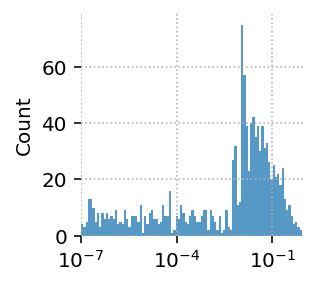

In [213]:

val_loss, last_loss = [], []
for mi in range(len(vocab_grouped)):
    out = torch.load(f'ICD_NeuroDetourLR5e-3noLN_out/ckpt_{vocab_grouped[mi]}.ckpt', weights_only=False)
    val_loss.append(out['best_loss'])
    last_loss.append(out['last_val_loss'])

custom_bins = np.logspace(-7, 0, 100)
plt.figure(figsize=(2,2))
sns.histplot(val_loss, bins=custom_bins)
plt.xlim(custom_bins.min(), custom_bins.max())
plt.xscale('log')

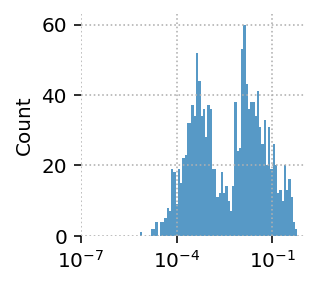

In [212]:

val_loss, last_loss = [], []
for mi in range(len(vocab_grouped)):
    out = torch.load(f'ICD_NeuroDetourLR1e-3noLN_out/ckpt_{vocab_grouped[mi]}.ckpt', weights_only=False)
    val_loss.append(out['best_loss'])
    last_loss.append(out['last_val_loss'])

custom_bins = np.logspace(-7, 0, 100)
plt.figure(figsize=(2,2))
sns.histplot(val_loss, bins=custom_bins)
plt.xlim(custom_bins.min(), custom_bins.max())
plt.xscale('log')

In [ ]:

val_loss, last_loss = [], []
for mi in range(len(vocab_grouped)):
    out = torch.load(f'ICD_NeuroDetourLR1e-3noLN_out/ckpt_{vocab_grouped[mi]}.ckpt', weights_only=False)
    val_loss.append(out['best_loss'])
    last_loss.append(out['last_val_loss'])

custom_bins = np.logspace(-7, 0, 100)
plt.figure(figsize=(2,2))
sns.histplot(val_loss, bins=custom_bins)
plt.xlim(custom_bins.min(), custom_bins.max())
plt.xscale('log')

## Plot AUC

In [190]:
def mix_age_group(group):
    n = len(group)
    mean = group['auc_delong'].mean()
    # Since we're taking the average, divide combined variance by n^2
    var = group['auc_variance_delong'].sum() / (n**2)
    
    case_score = []
    for s in group['case_score'].map(lambda x: [float(s) for s in x[1:-1].split()]):
        case_score.extend(s)
        
    control_score = []
    for s in group['control_score'].map(lambda x: [float(s) for s in x[1:-1].split()]):
        control_score.extend(s)
        
    return pd.Series({
        'auc': mean,
        'auc_variance_delong': var,
        'n_groups': n, 
        'n_diseased': group['n_diseased'].sum(),
        'n_healthy': group['n_healthy'].sum(),
        'case_score': case_score,
        'control_score': control_score,
    })


In [255]:
from sklearn.metrics import precision_recall_curve

                                       
top_rowi = np.where(pos_ratio<=0.1)[0]
# top_rowi = np.where(
i = 0
# for k in auc_df_dict:
for k in ['MLP', 'GCN', 'BrainGNN', 'BolT', 'BNT', 'Graphormer', 'NAGphormer', 'NeuroDetour']:
    auc_df = pd.read_csv(f'mia-exp_eval_out/auc_df_age-separate_{k}.csv')
    auc_df = auc_df.groupby(['token']).apply(mix_age_group, include_groups=False).reset_index()

    top_icd = auc_df[auc_df['token'].isin(top_rowi.tolist())]
    # top_icd = auc_df
    mask = np.array([s[0] in ['G', 'F'] for s in vocab_grouped[auc_df['token']]])
    mask = np.logical_and(mask, auc_df['token'].isin(top_rowi.tolist()))
    top_icd = auc_df[mask]
    
    pr = top_icd.apply(lambda x: precision_recall_curve(np.zeros(len(x['control_score'])).tolist()+np.ones(len(x['case_score'])).tolist(), x['control_score']+x['case_score']), axis=1)
    prec_avg, prec_std = pr.map(lambda x: x[0].mean()).mean(), pr.map(lambda x: x[0].mean()).std()
    rec_avg, rec_std = pr.map(lambda x: x[1].mean()).mean(), pr.map(lambda x: x[1].mean()).std()
    print(f"{rec_avg*100:.2f}+-{rec_std*100:.2f}", f"{prec_avg*100:.2f}+-{prec_std*100:.2f}", k)
    # break
    # precision_recall_curve(y_true, y_score)
    # auc = top_icd.apply(lambda x: get_auc_delong_var(x['control_score'], x['case_score'])[0], axis=1)
    # cov = top_icd.apply(lambda x: get_auc_delong_var(x['control_score'], x['case_score'])[1], axis=1)
    # avg, var = auc.mean(), auc.std()
    # avg, std = get_auc_delong_var(top_icd['control_score'], top_icd['case_score'])
    # print(f"{top_icd['auc'].mean()*100:.2f}+-{top_icd['auc'].std()*100:.2f}", k, vocab_grouped[top_rowi], pos_ratio[top_rowi])
    # print(vocab_grouped[top_rowi], pos_ratio[top_rowi])
    
    # print(f"{avg*100:.2f}+-{var*100:.2f}", k, (top_icd['n_diseased']/top_icd['n_healthy']).tolist())
    # print(auc.tolist(), cov.tolist())


51.43+-4.42 2.53+-0.81 MLP
56.71+-4.21 3.34+-1.38 GCN
52.47+-6.53 2.72+-1.29 BrainGNN
49.50+-5.36 2.60+-1.11 BolT
54.21+-3.54 2.92+-1.00 BNT
49.73+-6.13 2.45+-1.05 Graphormer
52.28+-3.37 2.79+-0.81 NAGphormer
46.97+-9.36 2.45+-1.26 NeuroDetour


In [292]:
vocab_grouped[np.where(pos_ratio>0.1)[0]], pos_ratio[np.where(pos_ratio>0.1)[0]]

(array(['E78', 'I10', 'K57', 'Z86'], dtype='<U3'),
 array([0.10293932, 0.19553425, 0.10861612, 0.16525798]))

In [244]:
top_rowi = np.where(pos_ratio>0.1)[0]
# top_rowi = np.where(pos_ratio>0.05)[0]
# top_rowi = np.where(
i = 0
# for k in auc_df_dict:
for k in ['MLP', 'GCN', 'BrainGNN', 'BolT', 'BNT', 'Graphormer', 'NAGphormer', 'NeuroDetour']:
    auc_df = pd.read_csv(f'mia-exp_eval_out/auc_df_age-separate_{k}.csv')
    auc_df = auc_df.groupby(['token']).apply(mix_age_group, include_groups=False).reset_index()

    top_icd = auc_df[auc_df['token'].isin(top_rowi.tolist())]
    # top_icd = auc_df
    # mask = np.array([s[0] in ['G', 'F'] for s in vocab_grouped[auc_df['token']]])
    # mask = np.logical_and(mask, auc_df['token'].isin(top_rowi.tolist()))
    # top_icd = auc_df[mask]
    auc = top_icd.apply(lambda x: get_auc_delong_var(x['control_score'], x['case_score'])[0], axis=1)
    cov = top_icd.apply(lambda x: get_auc_delong_var(x['control_score'], x['case_score'])[1], axis=1)
    avg, var = auc.mean(), auc.std()
    # avg, std = get_auc_delong_var(top_icd['control_score'], top_icd['case_score'])
    # print(f"{top_icd['auc'].mean()*100:.2f}+-{top_icd['auc'].std()*100:.2f}", k, vocab_grouped[top_rowi], pos_ratio[top_rowi])
    # print(vocab_grouped[top_rowi], pos_ratio[top_rowi])
    
    print(f"{avg*100:.2f}+-{var*100:.2f}", k, (top_icd['n_diseased']/top_icd['n_healthy']).tolist())
    # print(auc.tolist(), cov.tolist())


56.17+-2.46 MLP [0.08058198097369894, 0.19670128283445326, 0.10576923076923077, 0.1451048951048951]
51.69+-2.69 GCN [0.08058198097369894, 0.19670128283445326, 0.10576923076923077, 0.1451048951048951]
53.00+-1.83 BrainGNN [0.08058198097369894, 0.19670128283445326, 0.10576923076923077, 0.1451048951048951]
50.05+-2.31 BolT [0.08058198097369894, 0.19670128283445326, 0.10576923076923077, 0.1451048951048951]
55.63+-4.36 BNT [0.08058198097369894, 0.19670128283445326, 0.10576923076923077, 0.1451048951048951]
52.13+-1.66 Graphormer [0.08058198097369894, 0.19670128283445326, 0.10576923076923077, 0.1451048951048951]
54.81+-3.34 NAGphormer [0.08058198097369894, 0.19670128283445326, 0.10576923076923077, 0.1451048951048951]
57.63+-5.63 NeuroDetour [0.08058198097369894, 0.19670128283445326, 0.10576923076923077, 0.1451048951048951]


In [193]:
auc_df = pd.read_csv(f'mia-exp_eval_out/auc_df_age-separate_MLP.csv')
auc_df = auc_df.groupby(['token']).apply(mix_age_group, include_groups=False).reset_index()
auc_df

,token,auc,auc_variance_delong,n_groups,n_diseased,n_healthy,case_score,control_score
0,6,0.464889,0.002475,7,36,1872,"[0.05351404, 0.10756759, 0.0861972, 0.0867655,...","[0.1103169, 0.11434627, 0.07572189, 0.08280175..."
1,100,0.517908,0.004336,7,64,1832,"[0.02127504, 0.20616293, 0.09728086, 0.0429762...","[0.18367913, 0.13894702, 0.09830732, 0.1290725..."
2,105,0.591864,0.001056,7,52,1855,"[0.08815903, 0.15494098, 0.08766817, 0.2154735...","[0.06103228, 0.05889813, 0.05364782, 0.0592825..."
3,113,0.519803,0.002263,6,47,1252,"[0.05883972, 0.0305948, 0.03132975, 0.0542441,...","[0.07063746, 0.03568871, 0.04453217, 0.0536930..."
4,154,0.472247,0.001372,8,88,1842,"[0.14947763, 0.09546763, 0.13348402, 0.1106537...","[0.10389309, 0.04937743, 0.25758323, 0.1732757..."
...,...,...,...,...,...,...,...,...
93,1425,0.516401,0.000877,7,110,1818,"[0.21614067, 0.11009545, 0.02868702, 0.0708706...","[0.10106494, 0.11755059, 0.21539554, 0.0929778..."
94,1427,0.488086,0.001654,7,75,1841,"[1.0, 0.95758086, 0.96098167, 1.0, 0.88711923,...","[0.8998476, 0.94951385, 1.0, 0.9613854, 0.8950..."
95,1428,0.519502,0.003424,7,41,1857,"[0.83328694, 0.96049035, 0.9644271, 1.0, 0.913...","[0.9348259, 0.96769464, 1.0, 0.99779534, 0.888..."
96,1429,0.474279,0.001303,8,152,1786,"[0.1063459, 0.13383755, 0.0551357, 0.20991203,...","[0.11331047, 0.16903989, 0.13378614, 0.2028926..."


In [196]:
auc_df.apply(lambda x: len(x['case_score'])==x['n_diseased'], axis=1).all()

True